# Cross-task generalization between MOU and rDCM 

This notebook examines group‑level convergence of effective connectivity across rDCM and MOU using cross‑model decoding (train on one, test on the other), showing both capture BOLD propagation dynamics similarly.

## Environment setup & index configuration

In [83]:
import os
import os.path
from os.path import dirname, join as pjoin
import numpy as np

import scipy.linalg as spl
import scipy.io as sio
from scipy import stats, odr
from scipy.stats import sem
import scipy.stats as stt

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.patheffects as PathEffects
import matplotlib.colors as colors
from matplotlib.ticker import FormatStrFormatter
import matplotlib.patches as patches
from matplotlib.colors import LinearSegmentedColormap 


import seaborn as sb
import pandas as pd


from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold, GridSearchCV
from sklearn.linear_model import LogisticRegression, SGDClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis
from sklearn.metrics import confusion_matrix
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.pipeline import Pipeline, make_pipeline
from sklearn.feature_selection import RFE
from sklearn.decomposition import PCA

import networkx as nx

from pathlib import Path

# Jupyter magic commands
%matplotlib inline


# Index dictionary
conf = {
        'tasks'   : ['vfm','movie','rest'], 
        'eccen'   : ['fovea','para-fovea'], 
        'fovea'   : [ 
                    [0,2,4,6,8,10,12,14,16,18,20,22],  #  < fovea
                    [1,3,5,7,9,11,13,15,17,19,21,23],   #  > fovea
                    ],
        'roiname' : ['V1','V2','V3'], 
        'rois'    : [
                    [0,1,2,3,12,13,14,15],   # V1
                    [4,5,6,7,16,17,18,19],   # V2
                    [8,9,10,11,20,21,22,23]  # V3
                    ],
        'task'    : [
                    [0,1],     # retinotopy
                    [2,3,4,5], # movie watching
                    [6,7,8,9]  # resting state
                    ],

        'hemis'   : ['left', 'right'],
        'flows'   : ['outflow', 'inflow']
        }


conditions = conf['tasks']

### Load MOU Results

In [84]:
model = 'new_2021' 

out_path = "../../../temp/results_MOU/"
print("Loadding results from: ", Path(out_path).resolve())


# Initialize lists to store the loaded data
model_fit_list = []
model_error_list = []
J_mod_list = []
Sigma_mod_list = []
tau_x_list = []
tau_list = []

# Load the MOU results
model_fit = np.load(os.path.join(Path(out_path).resolve(), 'Fit_' + model + '.npy'))
model_error = np.load(os.path.join(Path(out_path).resolve(), 'Error_' + model + '.npy'))
J_mod = np.load(os.path.join(Path(out_path).resolve(), 'J_mod_' + model + '.npy'))
Sigma_mod = np.load(os.path.join(Path(out_path).resolve(), 'Sigma_mod_' + model + '.npy'))

# Print shapes of all arrays to determine the correct axis for subject removal
print("Current shapes before removal:")
print(f"model_fit: {model_fit.shape}")
print(f"model_error: {model_error.shape}")
print(f"J_mod: {J_mod.shape}")
print(f"Sigma_mod: {Sigma_mod.shape}")

Loadding results from:  /home/nicolas/Documents/GitHubProjects/retNet/temp/results_MOU
Current shapes before removal:
model_fit: (3, 156)
model_error: (3, 156)
J_mod: (3, 156, 24, 24)
Sigma_mod: (3, 156, 24, 24)


## Detect subjects with all-zero matrices in any condition

In [85]:
# Detect subjects with all-zero OFF-DIAGONAL elements in any condition
problematic_subjects_any_zero = []
num_subjects = J_mod.shape[1]
num_conditions = J_mod.shape[0]

for i_sub in range(num_subjects):
    is_problematic = False
    for cond_idx in range(num_conditions):
        matrix = J_mod[cond_idx, i_sub, :, :]
        # Create a copy and zero out the diagonal to check only off-diagonal elements
        off_diag_matrix = matrix.copy()
        np.fill_diagonal(off_diag_matrix, 0)
        
        # Check if all off-diagonal elements are zero (or very close to zero)
        if np.all(np.abs(off_diag_matrix) < 1e-10):
            print(f"Subject {i_sub}, Condition {cond_idx}: All off-diagonal elements are zero")
            is_problematic = True
            break
    if is_problematic:
        problematic_subjects_any_zero.append(i_sub)

print(f"\nSubjects with all-zero off-diagonal matrices in at least one condition: {problematic_subjects_any_zero}")
print(f"Total problematic subjects: {len(problematic_subjects_any_zero)}")

# Remove problematic subjects from all arrays (using the list from detection)
# Sort in descending order to avoid index shifting
problematic_subjects_sorted = sorted(problematic_subjects_any_zero, reverse=True)

# Remove from arrays using the correct subject axis for each
model_fit = np.delete(model_fit, problematic_subjects_sorted, axis=1)
model_error = np.delete(model_error, problematic_subjects_sorted, axis=1)
J_mod = np.delete(J_mod, problematic_subjects_sorted, axis=1)
Sigma_mod = np.delete(Sigma_mod, problematic_subjects_sorted, axis=1)


# Print shapes to verify removal
print("Shapes after removing problematic subjects:")
print(f"model_fit: {model_fit.shape}")
print(f"model_error: {model_error.shape}")
print(f"J_mod_array: {J_mod.shape}")
print(f"Sigma_mod: {Sigma_mod.shape}")


Subjects with all-zero off-diagonal matrices in at least one condition: []
Total problematic subjects: 0
Shapes after removing problematic subjects:
model_fit: (3, 156)
model_error: (3, 156)
J_mod_array: (3, 156, 24, 24)
Sigma_mod: (3, 156, 24, 24)


## Load rDCM results

In [86]:
model = 'rDCM_2024' 

out_path = "../../../temp/results_rDCM/"
print("Loading results from:", Path(out_path).resolve())

# Load pre-averaged results directly
EC_avg_dcm = np.load(os.path.join(out_path, "EC_avg_" + model + ".npy"))
diagonals_dcm = np.load(os.path.join(out_path, "diagonals_" + model + ".npy"))
F_avg_dcm = np.load(os.path.join(out_path, "F_avg_" + model + ".npy"))

print('EC_avg_dcm shape:', EC_avg_dcm.shape)      # Expected: (3, 156, 24, 24)
print('diagonals_dcm shape:', diagonals_dcm.shape) # Expected: (3, 156, 24)
print('F_avg_dcm shape:', F_avg_dcm.shape)         # Expected: (10, 156) or (3, 156) if you saved F_avg

Loading results from: /home/nicolas/Documents/GitHubProjects/retNet/temp/results_rDCM
EC_avg_dcm shape: (3, 156, 24, 24)
diagonals_dcm shape: (3, 156, 24)
F_avg_dcm shape: (3, 156)


## Reorder ROIs to highlight topology of connections


In [87]:
# Reorder indices: foveal then parafoveal, for each hemisphere
new_order = [0, 2, 4, 6, 8, 10, 1, 3, 5, 7, 9, 11,   # Left hemisphere
             12, 14, 16, 18, 20, 22, 13, 15, 17, 19, 21, 23]  # Right hemisphere

# Original ROI labels (repeats for left/right hemisphere)
rois = ['V1 vf', 'V1 vp', 'V1 df', 'V1 dp',
        'V2 vf', 'V2 vp', 'V2 df', 'V2 dp',
        'V3 vf', 'V3 vp', 'V3 df', 'V3 dp'] * 2

# Reordered labels
rois_sorted = [rois[i] for i in new_order]
print(rois_sorted)

['V1 vf', 'V1 df', 'V2 vf', 'V2 df', 'V3 vf', 'V3 df', 'V1 vp', 'V1 dp', 'V2 vp', 'V2 dp', 'V3 vp', 'V3 dp', 'V1 vf', 'V1 df', 'V2 vf', 'V2 df', 'V3 vf', 'V3 df', 'V1 vp', 'V1 dp', 'V2 vp', 'V2 dp', 'V3 vp', 'V3 dp']


## Normalize EC matrices 

To make EC matrices comparable across participants and conditions, each matrix is scaled by its L1 norm. This preserves relative differences in connection strengths while removing variations in overall magnitude.

In [6]:
def normalize_connectivity_matrices(EC_data, normalization_type='L1', verbose=True):
    """
    Normalize effective connectivity matrices using L1 or L2 normalization.
    
    Parameters
    ----------
    EC_data : ndarray
        Effective connectivity data with shape (n_conditions, n_subjects, n_rois, n_rois)
    normalization_type : str, optional
        Type of normalization to apply: 'L1' or 'L2' (default: 'L2')
        - 'L1': Normalize by sum of values (Manhattan norm)
        - 'L2': Normalize by Euclidean norm
    verbose : bool, optional
        Whether to print normalization information (default: True)
    
    Returns
    -------
    EC_normalized : ndarray
        Normalized connectivity matrices with same shape as input
    norm_name : str
        Name of the normalization method used
    
    Notes
    -----
    - Diagonal elements are set to zero before and after normalization
    - If the norm is zero, the matrix is returned unchanged
    """
    # Get dimensions
    n_cond, n_sub, n_rois, _ = EC_data.shape
    
    # Initialize output array
    EC_normalized = np.zeros((n_cond, n_sub, n_rois, n_rois))
    
    # Normalize each condition and subject
    for i_cond in range(n_cond):
        for i_sub in range(n_sub):

            # Get connectivity matrix for this condition and subject
            EC = EC_data[i_cond, i_sub, :, :].copy()
            np.fill_diagonal(EC, 0)  # zero out diagonal
            ECflat  = EC.flatten() # flatten the matrix
            

            # Get off-diagonal elements (link weights)
            EClinks = EC[~np.eye(EC.shape[0],dtype=bool)].reshape(EC.shape[0],-1) # ignore diagonal
            EClinks = EClinks.flatten() # flatten the links
            
            if normalization_type == 'L1':

                norm = sum(EClinks)                
                ECnorm  = ECflat / norm
                ECnorm  = ECnorm.reshape((n_rois, n_rois))

            elif normalization_type == 'L2':

                norm = np.sqrt(sum(EClinks)**2)                
                ECnorm  = ECflat / norm
                ECnorm  = ECnorm.reshape((n_rois, n_rois))
           
            
            # Ensure diagonal remains zero
            np.fill_diagonal(ECnorm, 0)
            
            # Store the normalized matrix
            EC_normalized[i_cond, i_sub, :, :] = ECnorm
    
    # Print information if verbose
    if verbose:
        print(f'EC shape: {EC_normalized.shape}, normalized using {normalization_type} norm')
    
    return EC_normalized


In [ ]:
def plot_connectivity_matrix(EC_data, output_filename, 
                             effect_size_threshold=0.1, 
                             rois_sorted=rois_sorted,
                             colorbar_label='EC',
                             use_latex=True):
    """
    Plot connectivity matrices with effect sizes for multiple conditions.
    
    Parameters
    ----------
    EC_data : ndarray
        Effective connectivity data with shape (n_conditions, n_subjects, n_rois, n_rois)
    output_filename : str
        Full path for saving the output figure
    effect_size_threshold : float, optional
        Threshold for displaying effect sizes (default: 0.1)
    colorbar_label : str, optional
        Label for the colorbar (default: 'EC')
    use_latex : bool, optional
        Whether to use LaTeX rendering for text (default: True)
    
    Returns
    -------
    fig : matplotlib.figure.Figure
        The created figure object
    ax : array of matplotlib.axes.Axes
        Array of axes objects
    effect_sizes : ndarray
        Computed effect sizes with shape (n_conditions, n_rois, n_rois)
    """
    # Set plot style
    if use_latex:
        plt.rcParams['text.usetex'] = True
        plt.rcParams['font.weight'] = 'bold'
        plt.rcParams['font.family'] = 'serif'
    
    
    # Cohen's d effect size function
    def cohen_d(group1, group2):
        """Calculate Cohen's d effect size between two groups."""
        mean1, mean2 = np.nanmean(group1), np.nanmean(group2)
        std1, std2 = np.nanstd(group1, ddof=1), np.nanstd(group2, ddof=1)
        n1, n2 = len(group1), len(group2)
        pooled_std = np.sqrt(((n1 - 1) * std1**2 + (n2 - 1) * std2**2) / (n1 + n2 - 2))
        d = (mean1 - mean2) / pooled_std
        return d
    
    # Get dimensions
    n_cond, n_sub, n_rois, _ = EC_data.shape
    
    # Calculate effect sizes
    effect_sizes = np.zeros((n_cond, n_rois, n_rois))
    for i_cond in range(n_cond):
        for roi_p in range(n_rois):
            for roi_q in range(n_rois):
                effect_sizes[i_cond, roi_p, roi_q] = cohen_d(
                    EC_data[i_cond, :, roi_p, roi_q],
                    EC_data[i_cond, :, :, :].flatten()
                )
    
    # Create figure
    fig, ax = plt.subplots(1, n_cond, figsize=(18, 6), dpi=300, facecolor="w")
    
    # Calculate color limits
    EC_min = np.min(np.nanmean(EC_data, axis=1).flatten())
    EC_max = np.max(np.nanmean(EC_data, axis=1).flatten())

    EC_valmax = np.max(np.abs(np.nanmean(EC_data, axis=1).flatten()))

    
    # Plot each condition
    for i_cond in range(n_cond):


        #divnorm = colors.TwoSlopeNorm(vmin=EC_min, vcenter=0, vmax=EC_max)
        divnorm = colors.TwoSlopeNorm(vmin=-EC_valmax, vcenter=0, vmax=EC_valmax)

        im = ax[i_cond].imshow(
            np.mean(EC_data[i_cond, :, :, :], axis=0).T,
            norm=divnorm, cmap='BrBG_r'
        )

        
        # Add effect size annotations
        for roi_p in range(n_rois):
            for roi_q in range(n_rois):
                if effect_sizes[i_cond, roi_p, roi_q] >= effect_size_threshold:
                    if roi_p != roi_q:  # Skip diagonal
                        txt = ax[i_cond].text(
                            roi_p, roi_q,
                            f'{effect_sizes[i_cond, roi_p, roi_q]:.1f}',
                            ha='center', va='center', color='black',
                            fontsize=8, rotation=30
                        )
                        txt.set_path_effects([
                            PathEffects.withStroke(linewidth=2, foreground='w')
                        ])
        
        # Set labels and ticks
        ax[i_cond].set_xlabel('Source ROI', fontsize=18)
        ax[i_cond].set_xticks(np.arange(len(rois_sorted)))
        ax[i_cond].set_xticklabels(labels=rois_sorted, rotation=90,fontsize=18)
        ax[i_cond].set_ylabel('Target ROI', fontsize=18)
        ax[i_cond].set_yticks(np.arange(len(rois_sorted)))
        ax[i_cond].set_yticklabels(labels=rois_sorted, rotation=0,fontsize=18)
        
        # Hide y-labels for subplots after the first
        if i_cond != 0:
            ax[i_cond].set_yticks(np.arange(len(rois_sorted)))
            ax[i_cond].set_yticklabels([''] * len(rois_sorted))
        
        # Set title
        ax[i_cond].set_title(conf['tasks'][i_cond], fontsize=24)
        
        # # Add colorbar to first subplot
        # if i_cond == 0:
        #     cbar = plt.colorbar(
        #         im,
        #         cax=fig.add_axes([0.32, -0.07, 0.18, 0.05]),
        #         extend='both',
        #         orientation='horizontal'
        #     )
        #     cbar.ax.tick_params(labelsize=14)
        #     cbar.set_label(f'EC (${colorbar_label}$)', fontsize=18)

        # Add colorbar to the right side (vertical)
        if i_cond == 0:  # Only add once, for the first subplot
            cbar = plt.colorbar(
                im,
                cax=fig.add_axes([0.92, 0.18, 0.02, 0.5]),  # Position: [left, bottom, width, height] for vertical bar
                extend='both',
                orientation='vertical'  # Changed to vertical
            )
            cbar.ax.tick_params(labelsize=14)
            cbar.set_label(f'EC (${colorbar_label}$)', fontsize=18)
    
    # Save figure
    print("file :", output_filename)
    plt.savefig(
        output_filename,
        transparent=None,
        dpi='figure',
        format='png',
        facecolor='auto',
        edgecolor='auto',
        bbox_inches='tight'
    )

    output_filename_svg = output_filename.replace('.png', '.svg')

    plt.savefig(output_filename_svg, transparent=None, dpi='figure', format='svg', facecolor='auto', edgecolor='auto', bbox_inches='tight')
    print("file :", output_filename_svg)
    
    return fig, ax, effect_sizes

In [8]:
EC_normed_MOU = normalize_connectivity_matrices(
    EC_data=J_mod,
    normalization_type='L1',
    verbose=True
)

EC_normed_rDCM = normalize_connectivity_matrices(
    EC_data=EC_avg_dcm,
    normalization_type='L1',
    verbose=True
)

EC shape: (3, 156, 24, 24), normalized using L1 norm
EC shape: (3, 156, 24, 24), normalized using L1 norm


## Reordering links according to connection topology

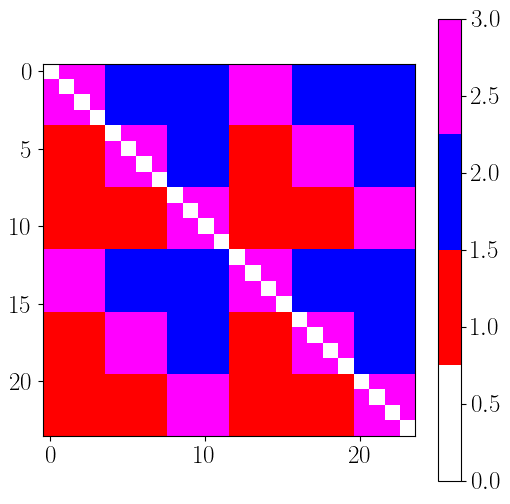

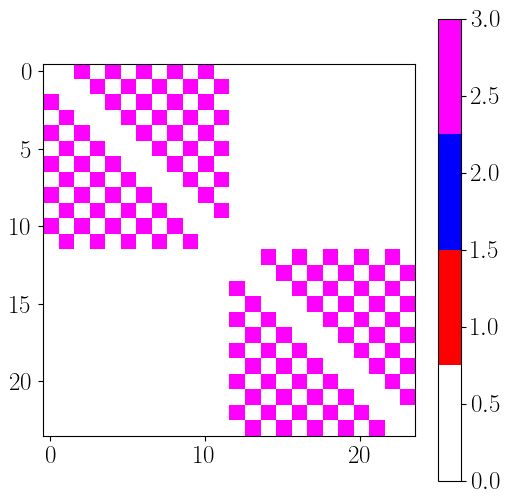

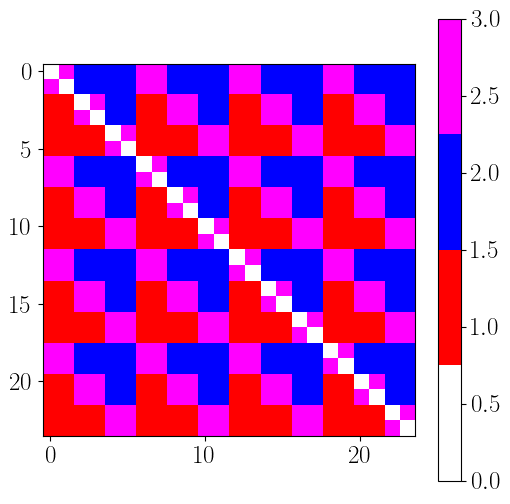

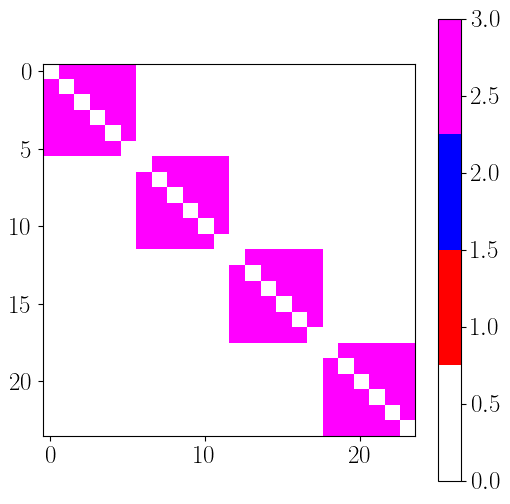

In [89]:
# Index dictionary
conf2 = {
    'eccentricity'    : ['fovea','periph'],
    'eccen_rois'      : [
                        [0,2,4,6,8,10,12,14,16,18,20,22],   #  fovea
                        [1,3,5,7,9,11,13,15,17,19,21,23]    #  periph
                        ],
    'hierarchy'       : ['V1','V2','V3'],
    'hier_rois'       : [
                        [0,1,2,3,12,13,14,15],  # V1
                        [4,5,6,7,16,17,18,19],  # V2
                        [8,9,10,11,20,21,22,23] # V3
                        ],
    'hemisphere'      : ['left', 'right'],
    'hemis_rois'      : [
                        [0,1,2,3,4,5,6,7,8,9,10,11],            #  left
                        [12,13,14,15,16,17,18,19,20,21,22,23]   #  right
                        ]
    }

n_rois = 24

eccentricity_index = np.zeros((n_rois))
eccentricity_index[[0,2,4,6,8,10,12,14,16,18,20,22]] = 0
eccentricity_index[[1,3,5,7,9,11,13,15,17,19,21,23]] = 1

hierarchy_index = np.zeros((n_rois))
hierarchy_index[[0,1,2,3,12,13,14,15]] = 0
hierarchy_index[[4,5,6,7,16,17,18,19]] = 1
hierarchy_index[[8,9,10,11,20,21,22,23]] = 2

hemisphere_index = np.zeros((n_rois))
hemisphere_index[[0,1,2,3,4,5,6,7,8,9,10,11]] = 0
hemisphere_index[[12,13,14,15,16,17,18,19,20,21,22,23]] = 1

# link type
# 1 : feedforward
# 2 : backforward
# 3 : lateral

cmap = colors.LinearSegmentedColormap.from_list('topo_cmap', ['white', 'red', 'blue', 'magenta'], N=4)

EC_topo = np.zeros((n_rois,n_rois))
for roi_p in range(n_rois): # source
    for roi_q in range(n_rois): # target
        if roi_p != roi_q :  # skip diagonal
            if hierarchy_index[roi_p] < hierarchy_index[roi_q] :
                EC_topo[roi_p, roi_q] = 1
            elif hierarchy_index[roi_p] > hierarchy_index[roi_q] :
                EC_topo[roi_p, roi_q] = 2
            else:
                EC_topo[roi_p, roi_q] = 3
            
plt.figure(figsize=(6,6))
plt.imshow(EC_topo.T, cmap=cmap, vmin=0, vmax=3)
plt.colorbar()


hierarchy_position = hemisphere_index

EC_topo2 = np.zeros((n_rois,n_rois))
for roi_p in range(n_rois): # source
    for roi_q in range(n_rois): # target
        if roi_p != roi_q and eccentricity_index[roi_p] == eccentricity_index[roi_q] and hemisphere_index[roi_p] == hemisphere_index[roi_q] :  # skip diagonal and non-homotopic links (same eccentricity and hemisphere)
            if hierarchy_position[roi_p] < hierarchy_position[roi_q] :
                EC_topo2[roi_p, roi_q] = 1
            elif hierarchy_position[roi_p] > hierarchy_position[roi_q] :
                EC_topo2[roi_p, roi_q] = 2
            else:
                EC_topo2[roi_p, roi_q] = 3

plt.figure(figsize=(6,6))
plt.imshow(EC_topo2.T, cmap=cmap, vmin=0, vmax=3)
plt.colorbar()


reorder_indices = [0,2,4,6,8,10,1,3,5,7,9,11,12,14,16,18,20,22,13,15,17,19,21,23]

EC_topo_reord = EC_topo[reorder_indices,:][:,reorder_indices]
EC_topo2_reord = EC_topo2[reorder_indices,:][:,reorder_indices]

plt.figure(figsize=(6,6))
plt.imshow(EC_topo_reord.T, cmap=cmap, vmin=0, vmax=3)
plt.colorbar()


plt.figure(figsize=(6,6))
plt.imshow(EC_topo2_reord.T, cmap=cmap, vmin=0, vmax=3)
plt.colorbar()

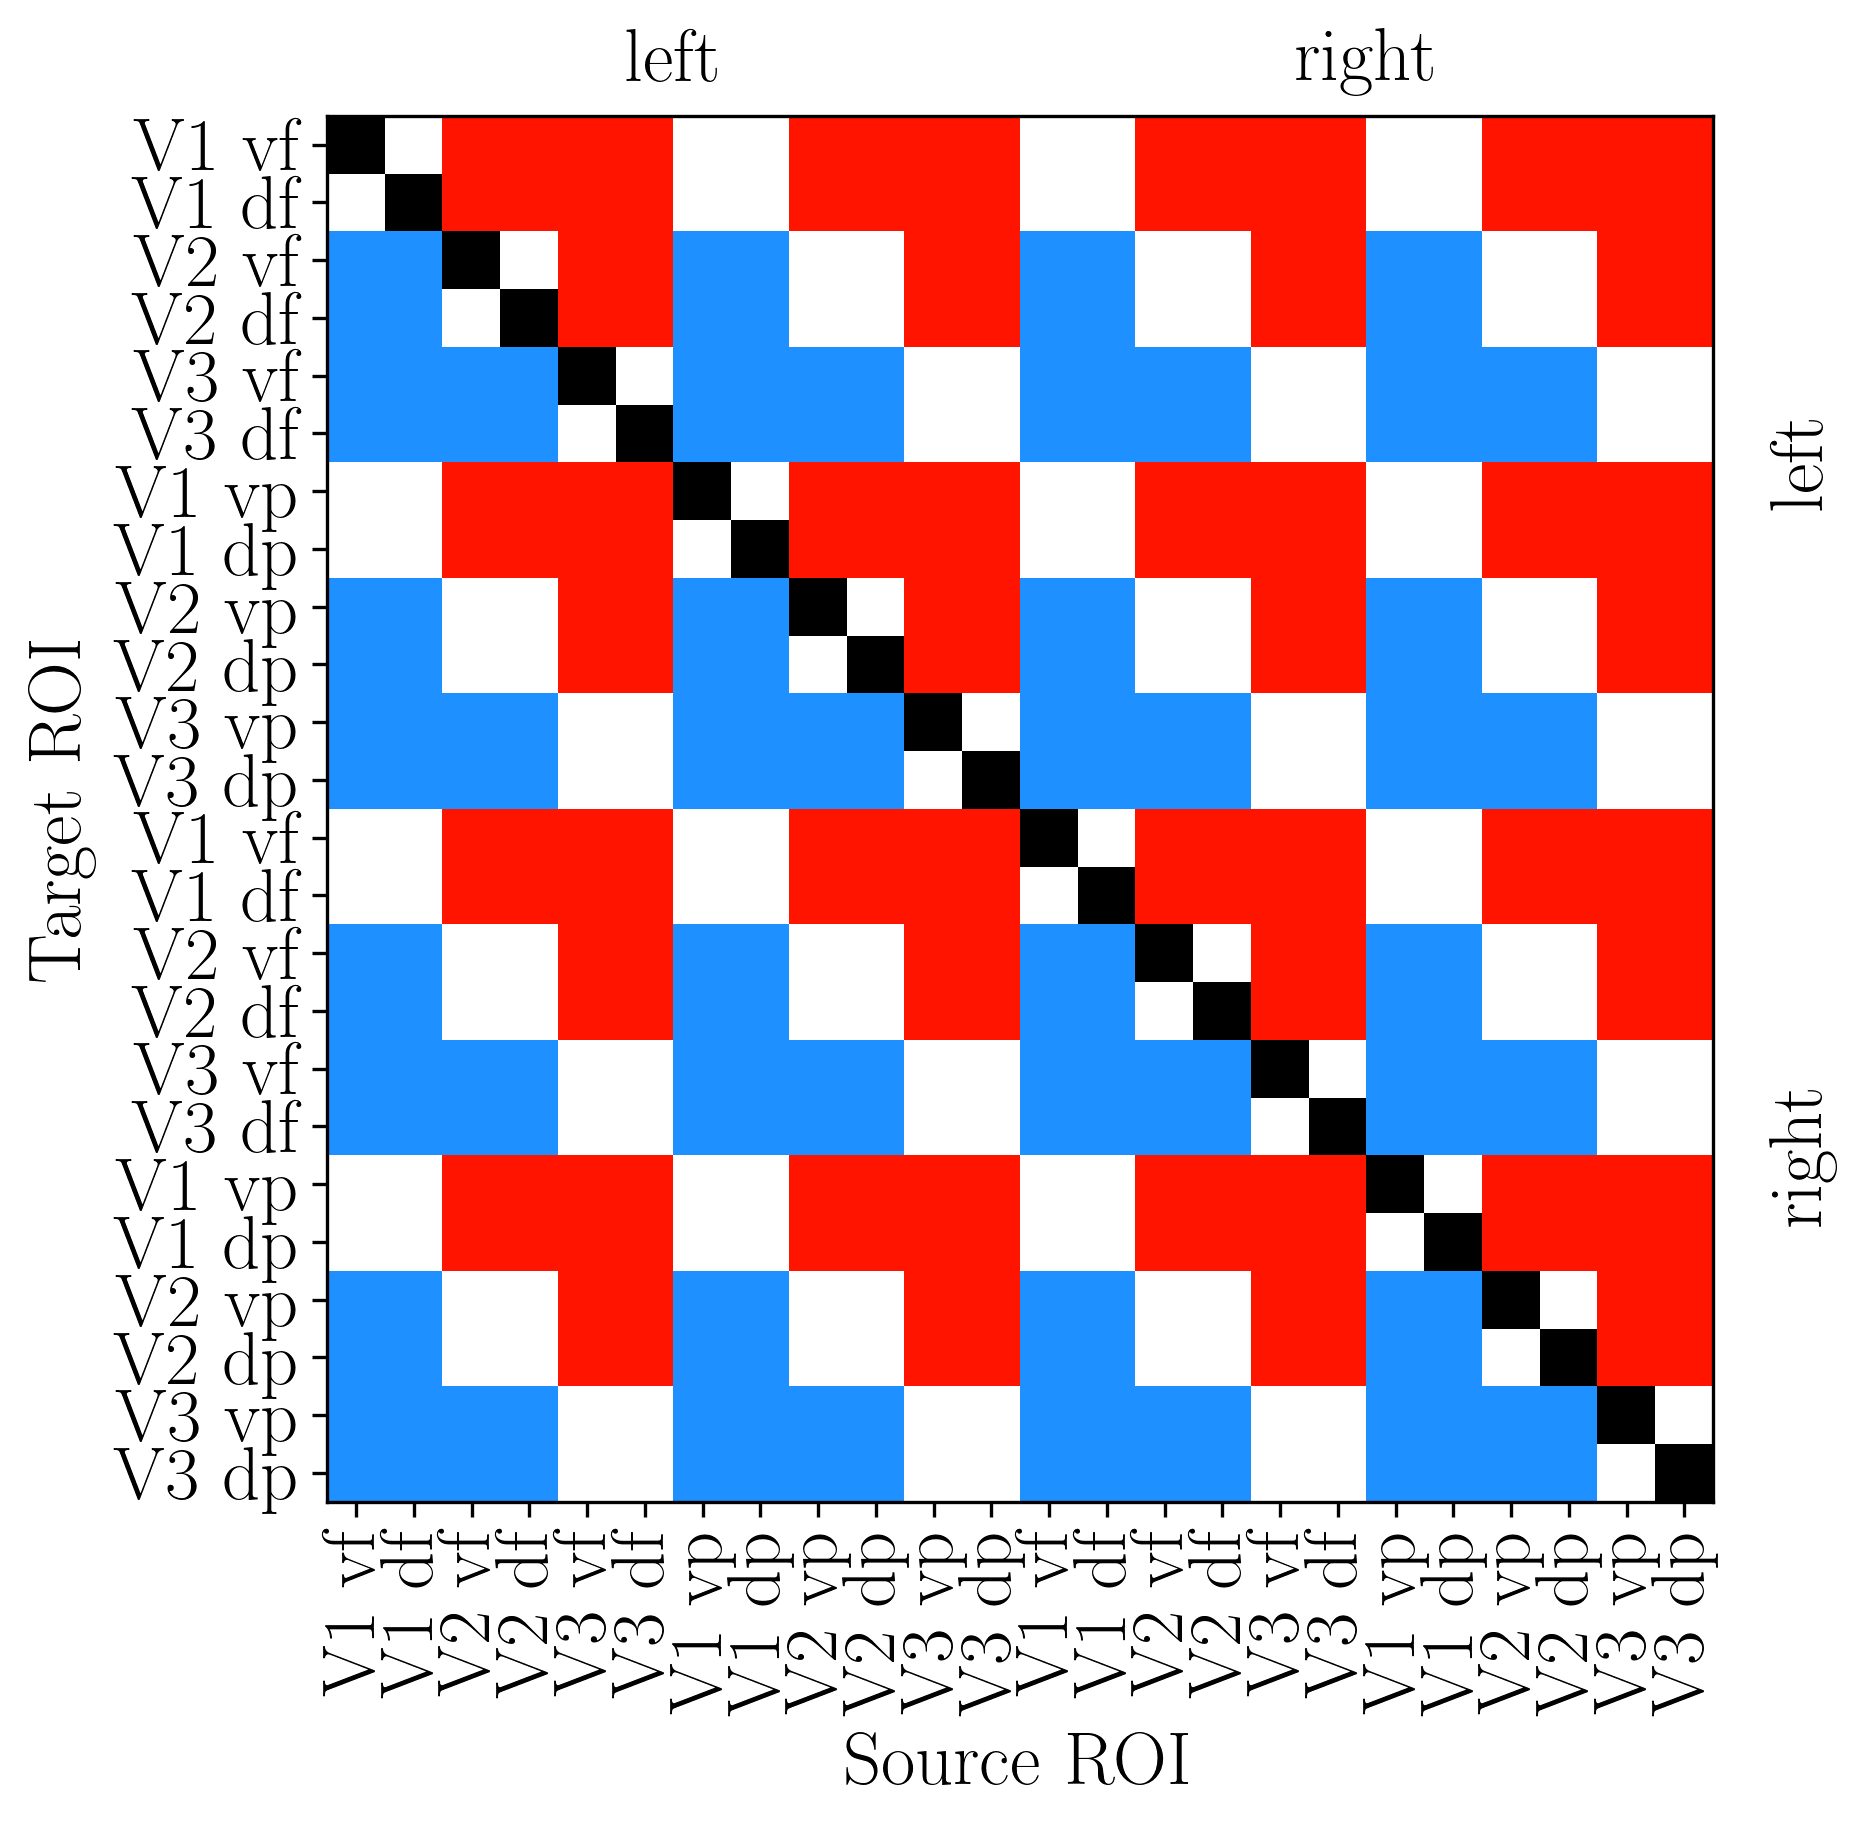

In [92]:
out_pth = '/media/nicolas/KINGSTON/retNet_final/output'

plt.rcParams.update({'text.usetex': True, 'font.weight': 'bold', 'font.family': 'serif'})

n_rois = 24

# Index arrays using numpy broadcasting
eccentricity_index = np.array([i % 2 for i in range(n_rois)])  # 0=foveal, 1=parafoveal
hierarchy_index = np.array([(i % 12) // 4 for i in range(n_rois)])  # 0=V1, 1=V2, 2=V3
hemisphere_index = np.array([i // 12 for i in range(n_rois)])  # 0=left, 1=right

# Build EC_topo: 1=feedforward, 2=feedback, 3=lateral
EC_topo = np.zeros((n_rois, n_rois))
for roi_p in range(n_rois):
    for roi_q in range(n_rois):
        if roi_p != roi_q:
            diff = hierarchy_index[roi_p] - hierarchy_index[roi_q]
            EC_topo[roi_p, roi_q] = 1 if diff < 0 else (2 if diff > 0 else 3)

# Colormap: black (diag), blue (FF), red (FB), white (lateral)
cmap = LinearSegmentedColormap.from_list('topo_cmap', ["#000000", '#1e90ff', "#ff1500", '#ffffff'], N=4)

# Plot
fig, ax = plt.subplots(figsize=(6, 6), dpi=300)
ax.imshow(EC_topo_reord.T, cmap=cmap, vmin=0, vmax=3)
ax.set_xticks(range(n_rois))
ax.set_xticklabels(rois_sorted, rotation=90, fontsize=18)
ax.set_yticks(range(n_rois))
ax.set_yticklabels(rois_sorted, fontsize=18)
ax.set_xlabel('Source ROI', fontsize=18)
ax.set_ylabel('Target ROI', fontsize=18)

# Hemisphere labels
for pos, label in [(5.5, 'left'), (17.5, 'right')]:
    ax.text(pos, -2, label, ha='center', va='top', fontsize=18, fontweight='bold')
    ax.text(24.5, pos, label, ha='left', va='center', fontsize=18, fontweight='bold', rotation=90)

    # Save the figure
fname = out_pth + '/topo_connectivity.svg'
plt.savefig(fname, transparent=None, dpi='figure', format='svg',
    facecolor='auto', edgecolor='auto', bbox_inches='tight')

plt.show()

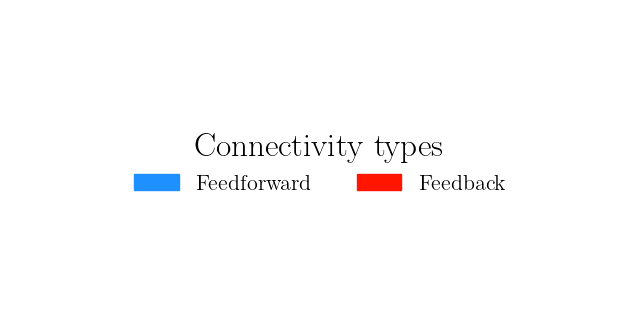

In [10]:
## Legend
color_list = ['#1e90ff',"#ff1500"]  
labels = ['Feedforward', 'Feedback']

fig, ax = plt.subplots(figsize=(8, 4))
ax.axis('off')  # Hide axes
handles = [patches.Patch(color=color, label=label) for color, label in zip(color_list, labels)]
ax.legend(handles=handles, loc='center', frameon=False, fontsize=16, title='Connectivity types', title_fontsize=24, ncol=2)

# Save the figure
fname = out_pth + '/connectivity_legend.svg'
plt.savefig(fname, transparent=None, dpi='figure', format='svg',
    facecolor='auto', edgecolor='auto', bbox_inches='tight')

plt.show()

In [94]:
EC_reordered = np.zeros_like(EC_normed_MOU)
for cond in range(EC_reordered.shape[0]):
    for subj in range(EC_reordered.shape[1]):
        EC_reordered[cond, subj] = EC_normed_MOU[cond, subj][np.ix_(new_order, new_order)]

file : /media/nicolas/KINGSTON/retNet_final/output/retNet24_MOU.png
file : /media/nicolas/KINGSTON/retNet_final/output/retNet24_MOU.svg


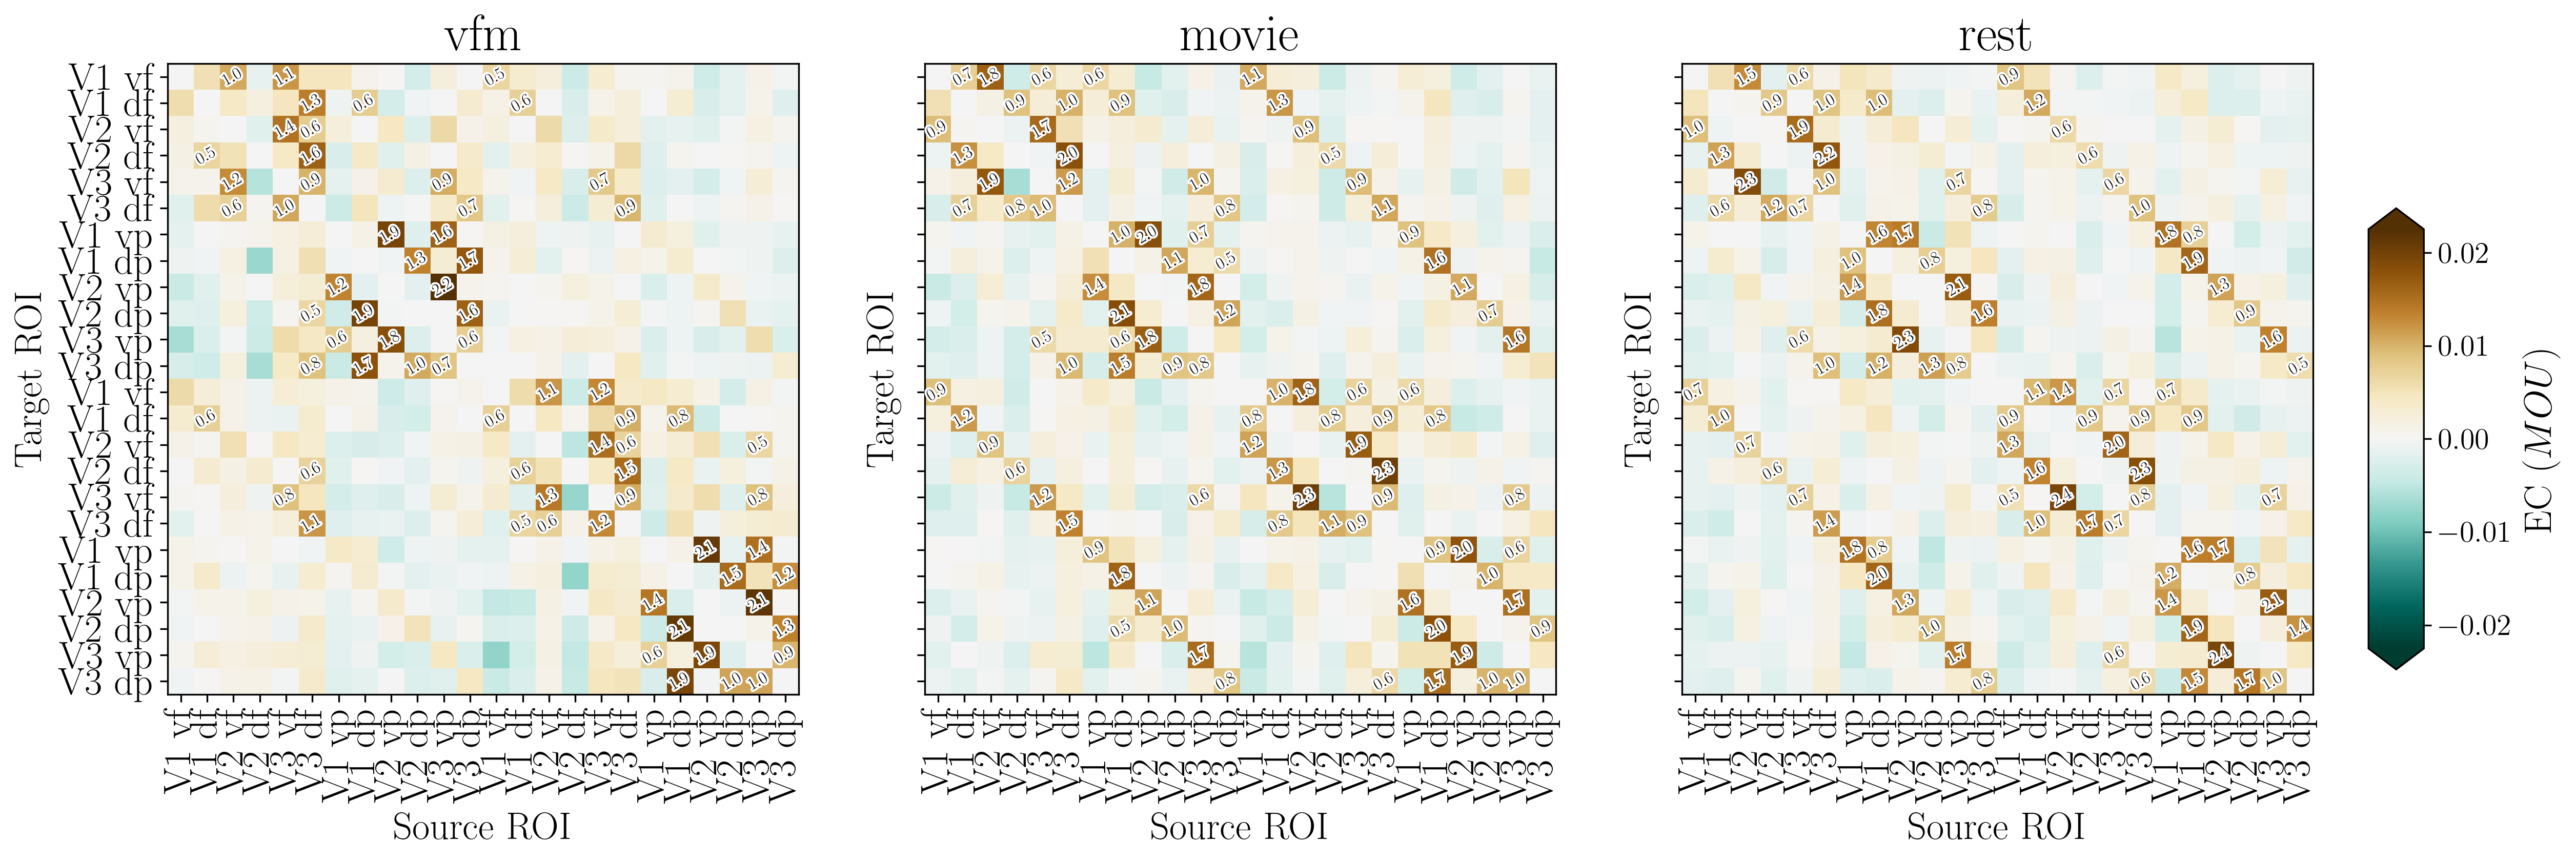

In [95]:
fig, ax, effect_sizes = plot_connectivity_matrix(
    EC_data=EC_reordered,
    rois_sorted=rois_sorted,
    output_filename=out_pth + '/retNet24_MOU.png',
    effect_size_threshold=0.5,
    colorbar_label='MOU'
)

In [96]:
EC_reordered = np.zeros_like(EC_normed_rDCM)
for cond in range(EC_reordered.shape[0]):
    for subj in range(EC_reordered.shape[1]):
        EC_reordered[cond, subj] = EC_normed_rDCM[cond, subj][np.ix_(new_order, new_order)]

file : /media/nicolas/KINGSTON/retNet_final/output/retNet24_rDCM.png
file : /media/nicolas/KINGSTON/retNet_final/output/retNet24_rDCM.svg


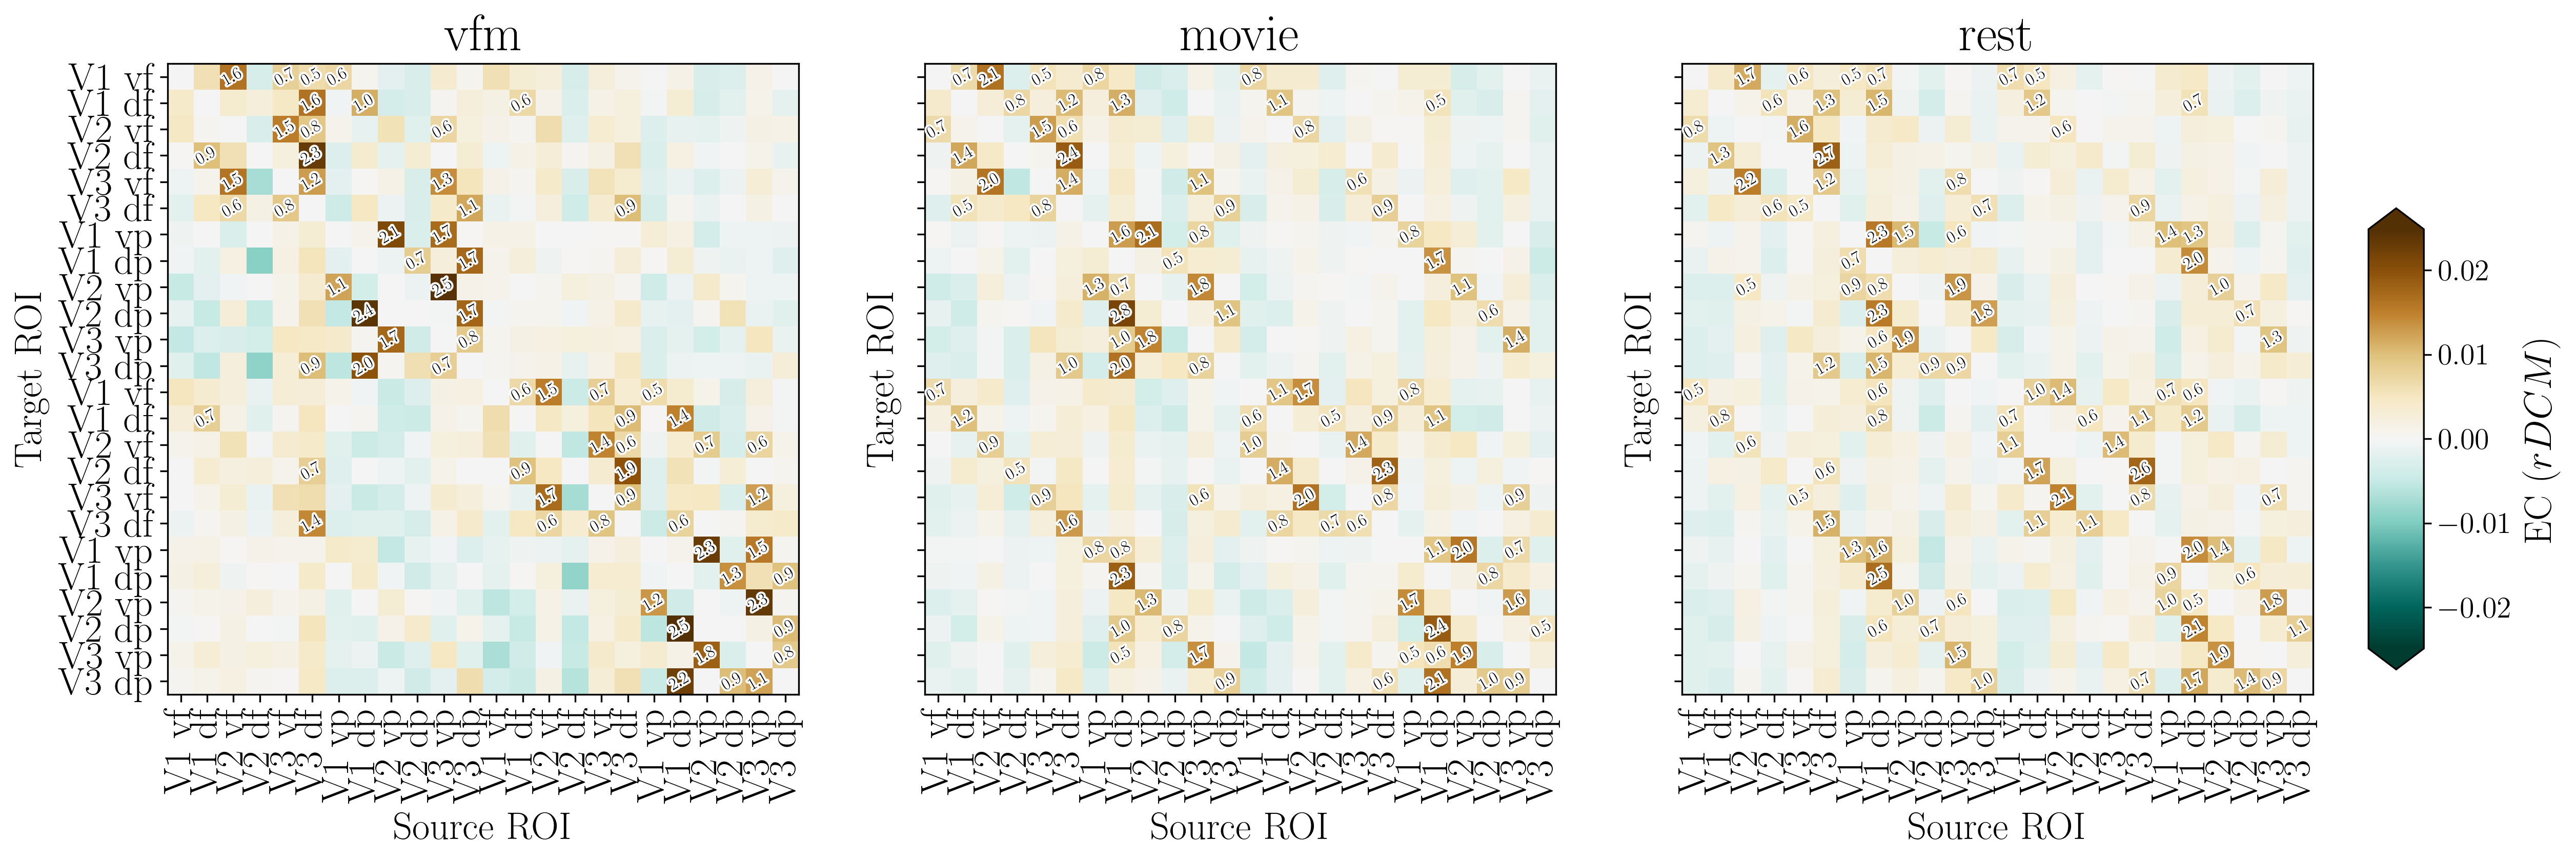

In [97]:
fig, ax, effect_sizes = plot_connectivity_matrix(
    EC_data=EC_reordered,
    rois_sorted=rois_sorted,
    output_filename=out_pth + '/retNet24_rDCM.png',
    effect_size_threshold=0.5,
    colorbar_label='rDCM'
)

## Within and across model task classification

In [15]:
X_mou = EC_normed_MOU.reshape((3*156,24*24))
X_dcm = EC_normed_rDCM.reshape((3*156,24*24))

y = np.repeat(np.arange(3).reshape(3,1),156,axis=1).reshape((3*156))

gp_sub =  np.repeat(np.arange(156).reshape(1,156),3,axis=0).reshape((3*156))

print(np.repeat(np.arange(3).reshape(3,1),4,axis=1))
print(np.repeat(np.arange(4).reshape(1,4),3,axis=0))

print('X mou : ', X_mou.shape)

[[0 0 0 0]
 [1 1 1 1]
 [2 2 2 2]]
[[0 1 2 3]
 [0 1 2 3]
 [0 1 2 3]]
X mou :  (468, 576)


### Classifier Setup and Training

In [16]:
# Classifiers (with reproducible random_state)
clf_MLR = LogisticRegression(penalty='l2', solver='lbfgs', max_iter=500, random_state=0)

clf_RF  = RandomForestClassifier(n_estimators=100, random_state=0)

# Map short names to estimators
dict_clf = {
    'MLR': clf_MLR,
    'RF' : clf_RF
}

# Per-classifier hyperparameter grids for GridSearchCV
dict_params = {
    'C': [0.01, 0.1, 1.0, 10.0, 100.0],      
    'n_estimators': [10, 50, 100],
    'criterion': ['gini', 'entropy']
    
}

In [17]:
# outer cross-validation scheme: 80% for training and 20% for testing
cvs = StratifiedShuffleSplit(n_splits=50, test_size=0.2)

 # nested cross-validation scheme
n_split_nest = 5
cv_nest = StratifiedKFold(n_splits=n_split_nest)

In [18]:
X = X_mou

X = X / np.std(X)

# to store result accuracies
acc = pd.DataFrame()

# Initialize confusion matrices for each classifier
CM_dict = {}
for k in dict_clf.keys():
    CM_dict[k] = np.zeros((3,3))

# loop over classifiers
for i, (k, param_name) in enumerate(zip(dict_clf,dict_params)):
    # get classifier and related information
    clf = dict_clf[k]
    param_vals = dict_params[param_name]
    # print(param_name, param_vals)

    # repeat classification
    for train_ind, test_ind in cvs.split(X, y, groups=gp_sub):
        # grid search for hyperparameter C
        gscv = GridSearchCV(clf,
                    {param_name: param_vals},
                    cv=cv_nest)
        gscv.fit(X[train_ind,:], y[train_ind])
        best_clf = gscv.best_estimator_
        print(gscv.best_params_)

        # train and test best classifier with subject labels
        best_clf.fit(X[train_ind,:], y[train_ind])
        # train and test accuracies
        d = {'type': ['train'],
             'clf': [k], 
             'score': [best_clf.score(X[train_ind,:], y[train_ind])]}
        acc = pd.concat((acc, pd.DataFrame(data=d)), ignore_index=True)
        d = {'type': ['test'],
             'clf': [k], 
             'score': [best_clf.score(X[test_ind,:], y[test_ind])]}
        acc = pd.concat((acc, pd.DataFrame(data=d)), ignore_index=True)

        # Add confusion matrix for this specific classifier
        CM_dict[k] += confusion_matrix(y[test_ind], best_clf.predict(X[test_ind,:]))

        # shuffling labels and fit again for evaluation of chance level
        train_ind_rand = np.random.permutation(train_ind)
        best_clf.fit(X[train_ind,:], y[train_ind_rand])
        d = {'type': ['shuf'],
             'clf': [k], 
             'score': [best_clf.score(X[test_ind,:], y[test_ind])]}
        acc = pd.concat((acc, pd.DataFrame(data=d)), ignore_index=True)

        
# print table of results
print(acc)

# Print confusion matrices for each classifier
for k in dict_clf.keys():
    print(f"\nConfusion Matrix for {k}:")
    print(CM_dict[k])

{'C': 10.0}
{'C': 1.0}
{'C': 0.01}
{'C': 0.01}
{'C': 1.0}
{'C': 0.01}
{'C': 10.0}
{'C': 1.0}
{'C': 10.0}
{'C': 0.1}
{'C': 1.0}
{'C': 1.0}
{'C': 1.0}
{'C': 1.0}
{'C': 1.0}
{'C': 0.01}
{'C': 0.01}
{'C': 0.1}
{'C': 1.0}
{'C': 100.0}
{'C': 0.1}
{'C': 0.01}
{'C': 10.0}
{'C': 0.1}
{'C': 1.0}
{'C': 0.1}
{'C': 0.1}
{'C': 0.01}
{'C': 100.0}
{'C': 0.01}
{'C': 1.0}
{'C': 0.1}
{'C': 1.0}
{'C': 1.0}
{'C': 0.1}
{'C': 100.0}
{'C': 0.1}
{'C': 1.0}
{'C': 1.0}
{'C': 10.0}
{'C': 0.1}
{'C': 0.1}
{'C': 1.0}
{'C': 0.1}
{'C': 0.01}
{'C': 0.1}
{'C': 1.0}
{'C': 0.1}
{'C': 1.0}
{'C': 0.01}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 50}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 50}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimator

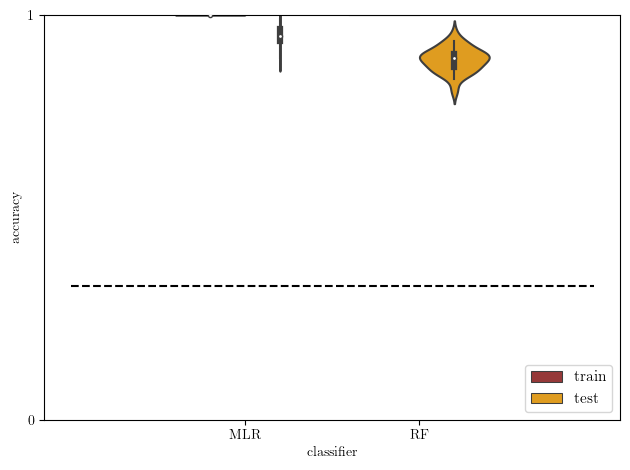

In [19]:
# plot: train versus test accuracy
acc2 = acc[np.logical_or(acc['type']=='train',acc['type']=='test')]

# theoretical chance level
chance_level = 0.33

sb.violinplot(data=acc2, x='clf', y='score', hue='type',
              density_norm='width', palette=['brown','orange'])
plt.plot([-1,2], [chance_level]*2, '--k')
plt.yticks([0,1])
plt.xlabel('classifier')
plt.ylabel('accuracy')
plt.ylim(0, 1)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

In [20]:
mlr_train_mou = acc[(acc['type'] == 'train') & (acc['clf'] == 'MLR')]
mlr_test_mou = acc[(acc['type'] == 'test') & (acc['clf'] == 'MLR')]
mlr_shuffle_mou = acc[(acc['type'] == 'shuf') & (acc['clf'] == 'MLR')]

rf_train_mou = acc[(acc['type'] == 'train') & (acc['clf'] == 'RF')]  
rf_test_mou = acc[(acc['type'] == 'test') & (acc['clf'] == 'RF')]    
rf_shuffle_mou = acc[(acc['type'] == 'shuf') & (acc['clf'] == 'RF')]

dist_mou = np.vstack((mlr_train_mou['score'], mlr_test_mou['score'], mlr_shuffle_mou['score'], rf_train_mou['score'], rf_test_mou['score'], rf_shuffle_mou['score']))

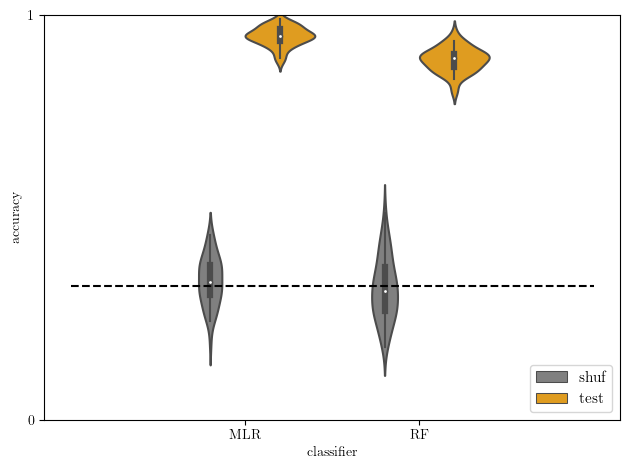

In [21]:
# test versus baseline accuracy
acc2 = acc[np.logical_or(acc['type']=='shuf',acc['type']=='test')]

sb.violinplot(data=acc2, x='clf', y='score', hue='type', hue_order=['shuf','test'], 
              density_norm='width', palette=['gray','orange'])
plt.plot([-1,2], [chance_level]*2, '--k')
plt.yticks([0,1])
plt.xlabel('classifier')
plt.ylabel('accuracy')
plt.ylim(0, 1)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

In [22]:
# Imports moved to top cell

# Set font configuration
font = {'family' : 'DejaVu Sans',
        'weight' : 'regular',
        'size'   : 18}
mpl.rc('font', **font)

/tmp/ipykernel_208241/3035824812.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


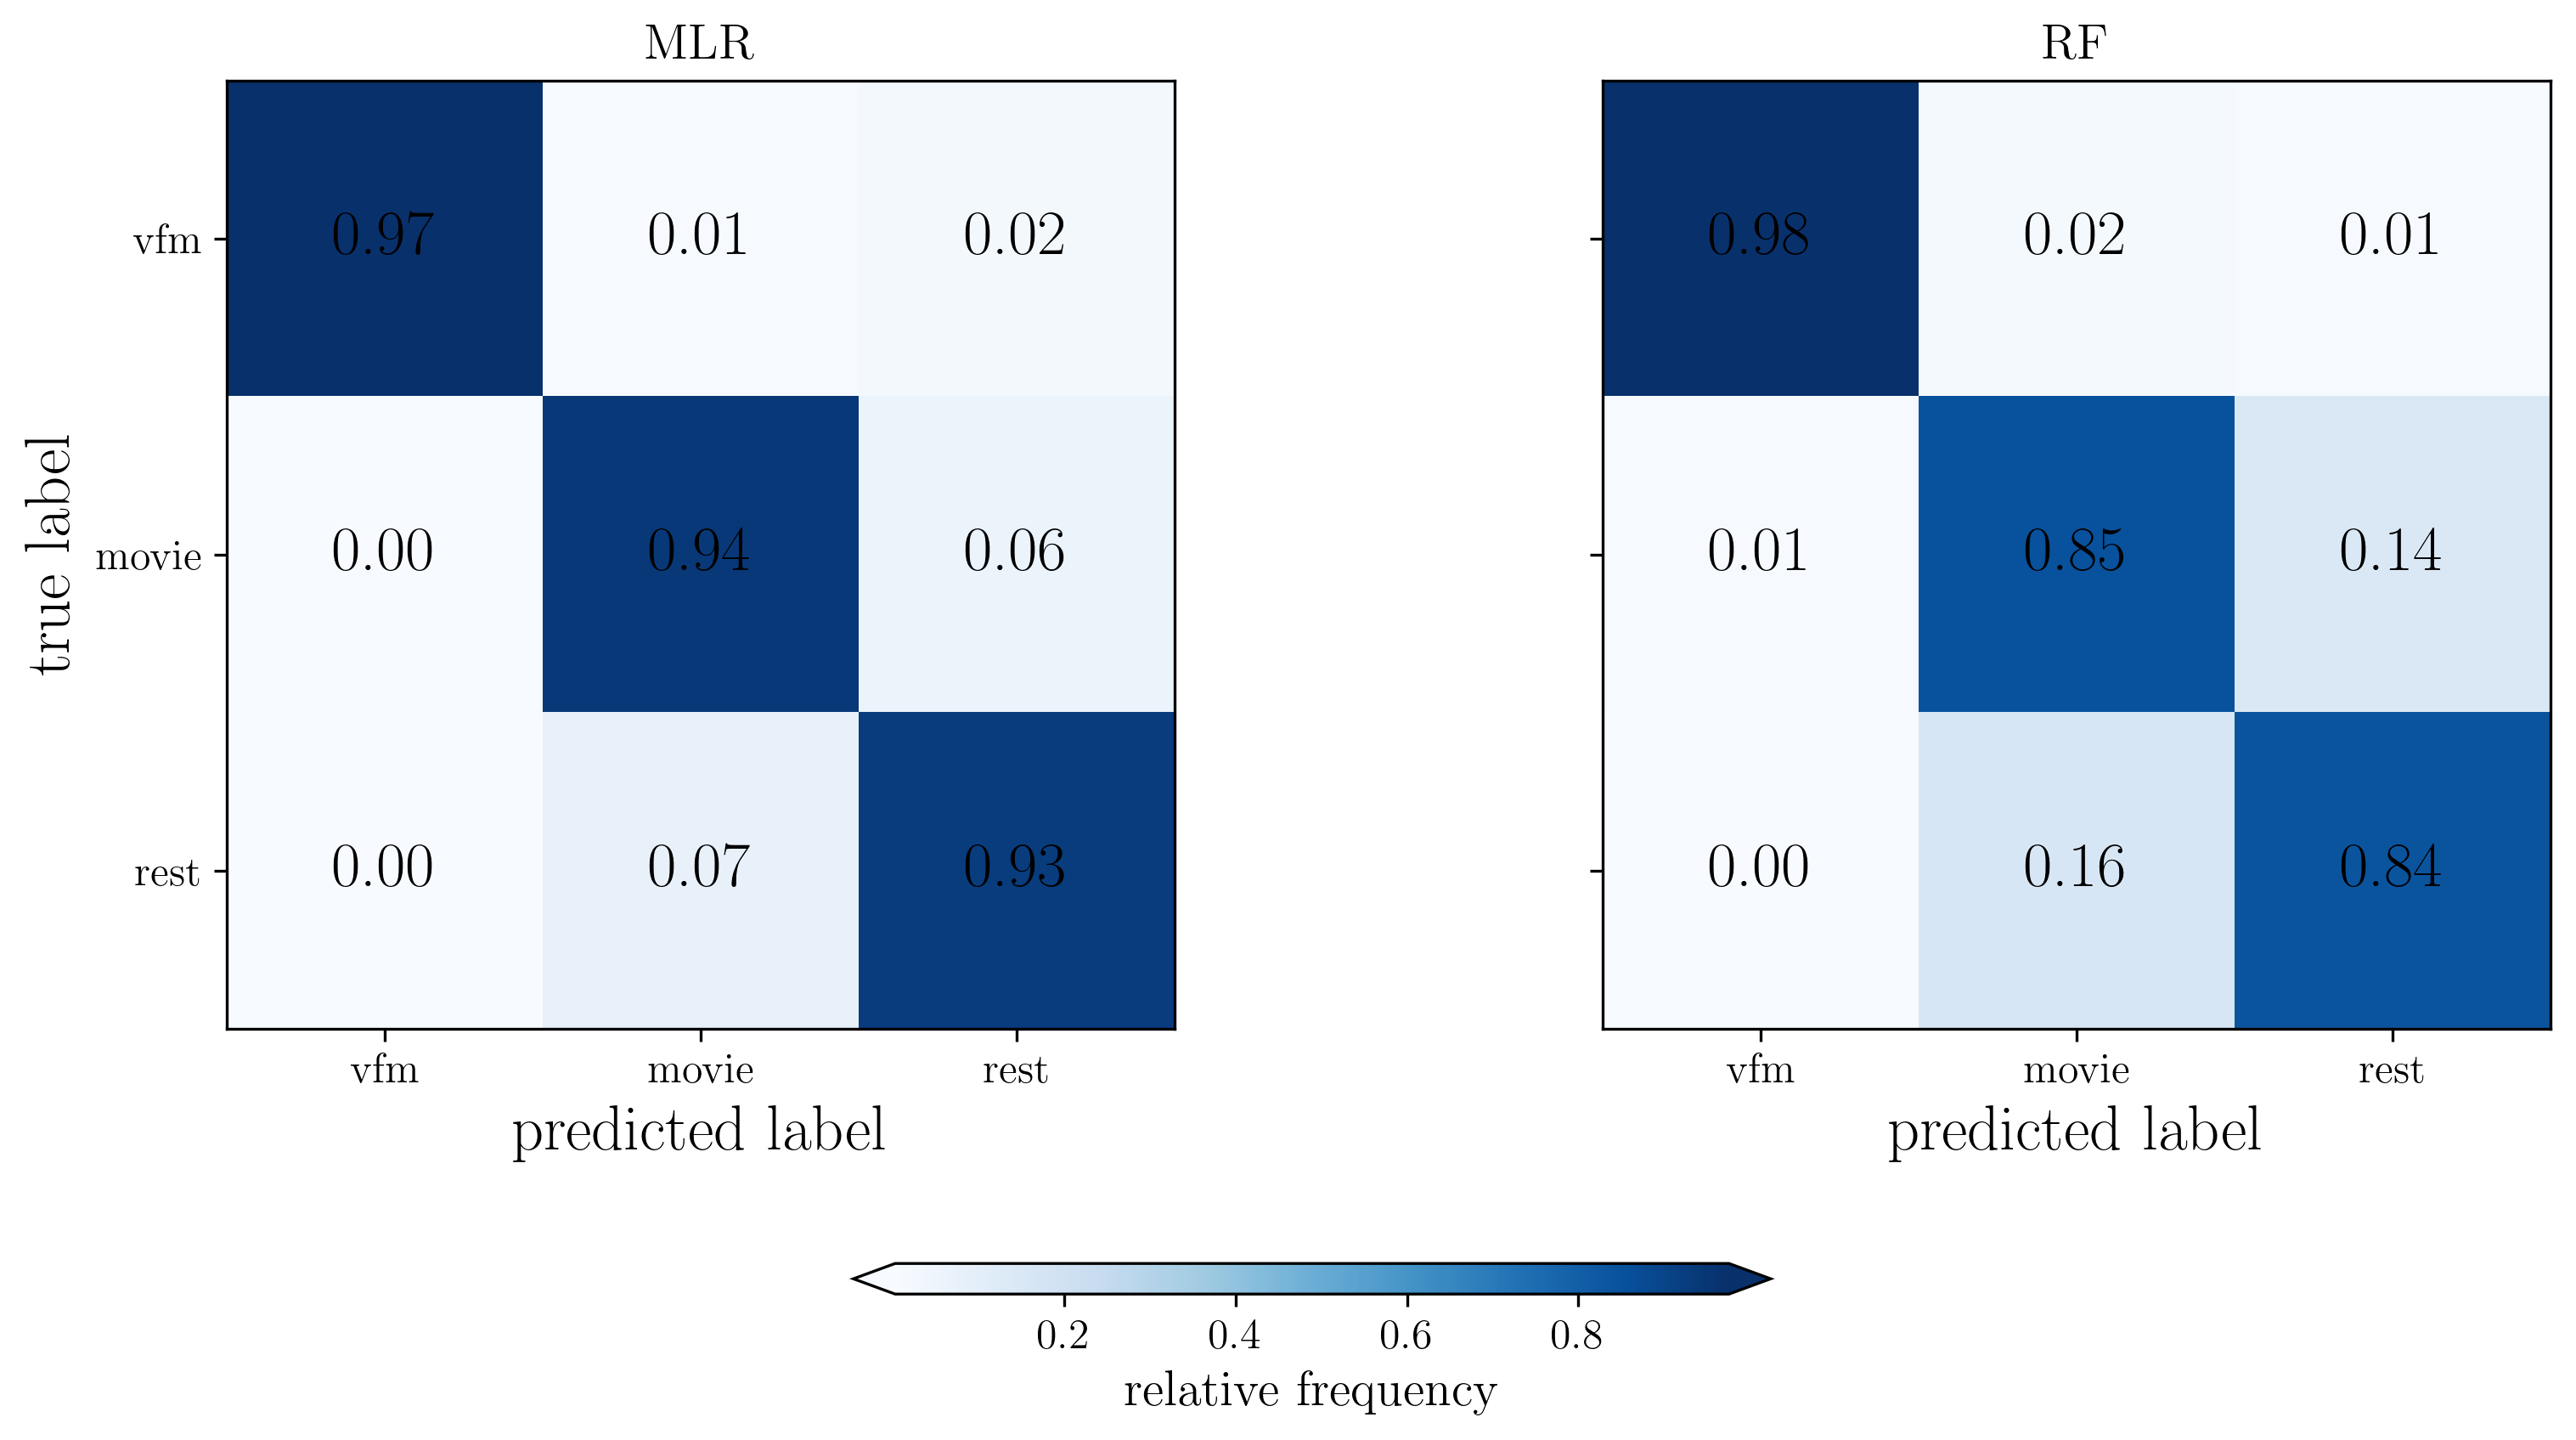

In [23]:
# Normalize confusion matrices
CM_mou_mlr = CM_dict['MLR'] / np.sum(CM_dict['MLR'], axis=1)[:,np.newaxis]
CM_mou_rf = CM_dict['RF'] / np.sum(CM_dict['RF'], axis=1)[:,np.newaxis]

fig, ax = plt.subplots(1,2, figsize=(12,5), dpi=300, facecolor="w")

# Plot MLR confusion matrix
im1 = ax[0].imshow(CM_mou_mlr, cmap='Blues', interpolation='nearest')
ax[0].set_ylabel('true label')
ax[0].set_xlabel('predicted label')
ax[0].set_title('MLR', fontsize=14)
ax[0].set_xticks(range(3), ['vfm','movie','rest'], fontsize=12)
ax[0].set_yticks(range(3), ['vfm','movie','rest'], fontsize=12)

# Add text annotations for MLR
for i in range(3):
    for j in range(3):
        text = ax[0].text(j, i, f'{CM_mou_mlr[i, j]:.2f}',
                         ha="center", va="center", color="black", fontweight='bold')

# Plot RF confusion matrix  
im2 = ax[1].imshow(CM_mou_rf, cmap='Blues', interpolation='nearest')
ax[1].set_xlabel('predicted label')
ax[1].set_title('RF', fontsize=14)
ax[1].set_xticks(range(3), ['vfm','movie','rest'], fontsize=12)
ax[1].set_yticks(range(3))
labels = [item.get_text() for item in ax[1].get_yticklabels()]
empty_string_labels = ['']*len(labels)
ax[1].set_yticklabels(empty_string_labels)

# Add text annotations for RF
for i in range(3):
    for j in range(3):
        text = ax[1].text(j, i, f'{CM_mou_rf[i, j]:.2f}',
                         ha="center", va="center", color="black", fontweight='bold')

# Add colorbar (moved further down)
cbar = plt.colorbar(im2, cax=fig.add_axes([0.35, -0.05, 0.3, 0.024]), 
                   extend='both', orientation='horizontal')     
cbar.ax.tick_params(labelsize=12)
cbar.set_label('relative frequency', fontsize=14)

plt.tight_layout()

fname = out_pth + 'confMat_MOU_both.svg' 
plt.savefig(fname, transparent=None, dpi='figure', format='svg',
    facecolor='auto', edgecolor='auto', bbox_inches='tight')

plt.show()

In [24]:
X = X_dcm

X = X / np.std(X)

# to store result accuracies
acc = pd.DataFrame()

# Initialize confusion matrices for each classifier
CM_dict = {}
for k in dict_clf.keys():
    CM_dict[k] = np.zeros((3,3))

# loop over classifiers
for i, (k, param_name) in enumerate(zip(dict_clf,dict_params)):
    # get classifier and related information
    clf = dict_clf[k]
    param_vals = dict_params[param_name]
    # print(param_name, param_vals)

    # repeat classification
    for train_ind, test_ind in cvs.split(X, y, groups=gp_sub):
        # grid search for hyperparameter C
        gscv = GridSearchCV(clf,
                    {param_name: param_vals},
                    cv=cv_nest)
        gscv.fit(X[train_ind,:], y[train_ind])
        best_clf = gscv.best_estimator_
        print(gscv.best_params_)

        # train and test best classifier with subject labels
        best_clf.fit(X[train_ind,:], y[train_ind])
        # train and test accuracies
        d = {'type': ['train'],
             'clf': [k], 
             'score': [best_clf.score(X[train_ind,:], y[train_ind])]}
        acc = pd.concat((acc, pd.DataFrame(data=d)), ignore_index=True)
        d = {'type': ['test'],
             'clf': [k], 
             'score': [best_clf.score(X[test_ind,:], y[test_ind])]}
        acc = pd.concat((acc, pd.DataFrame(data=d)), ignore_index=True)

        # Add confusion matrix for this specific classifier
        CM_dict[k] += confusion_matrix(y[test_ind], best_clf.predict(X[test_ind,:]))

        # shuffling labels and fit again for evaluation of chance level
        train_ind_rand = np.random.permutation(train_ind)
        best_clf.fit(X[train_ind,:], y[train_ind_rand])
        d = {'type': ['shuf'],
             'clf': [k], 
             'score': [best_clf.score(X[test_ind,:], y[test_ind])]}
        acc = pd.concat((acc, pd.DataFrame(data=d)), ignore_index=True)

           
# print table of results
print(acc)

# Print confusion matrices for each classifier
for k in dict_clf.keys():
    print(f"\nConfusion Matrix for {k} (DCM):")
    print(CM_dict[k])

{'C': 100.0}
{'C': 1.0}
{'C': 1.0}
{'C': 1.0}
{'C': 0.1}
{'C': 1.0}
{'C': 1.0}
{'C': 0.1}
{'C': 100.0}
{'C': 0.1}
{'C': 0.1}
{'C': 0.1}
{'C': 100.0}
{'C': 0.1}
{'C': 10.0}
{'C': 1.0}
{'C': 0.01}
{'C': 0.1}
{'C': 0.1}
{'C': 10.0}
{'C': 0.01}
{'C': 0.01}
{'C': 0.1}
{'C': 0.1}
{'C': 0.1}
{'C': 100.0}
{'C': 10.0}
{'C': 0.1}
{'C': 0.1}
{'C': 0.1}
{'C': 10.0}
{'C': 10.0}
{'C': 1.0}
{'C': 0.1}
{'C': 0.01}
{'C': 0.1}
{'C': 100.0}
{'C': 0.01}
{'C': 0.1}
{'C': 0.01}
{'C': 1.0}
{'C': 0.1}
{'C': 1.0}
{'C': 0.1}
{'C': 0.1}
{'C': 1.0}
{'C': 10.0}
{'C': 10.0}
{'C': 100.0}
{'C': 0.1}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 50}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 50}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estim

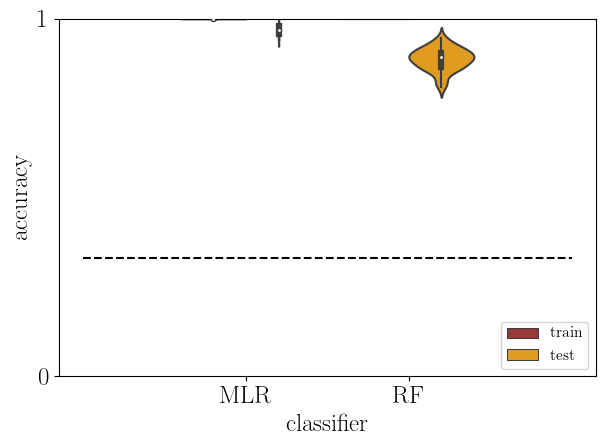

In [25]:
# plot: train versus test accuracy
acc2 = acc[np.logical_or(acc['type']=='train',acc['type']=='test')]

# theoretical chance level
chance_level = 0.33

sb.violinplot(data=acc2, x='clf', y='score', hue='type',
              density_norm='width', palette=['brown','orange'])
plt.plot([-1,2], [chance_level]*2, '--k')
plt.yticks([0,1])
plt.xlabel('classifier')
plt.ylabel('accuracy')
plt.ylim(0, 1)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

In [26]:
mlr_train_dcm = acc[(acc['type'] == 'train') & (acc['clf'] == 'MLR')]
mlr_test_dcm = acc[(acc['type'] == 'test') & (acc['clf'] == 'MLR')]
mlr_shuffle_dcm = acc[(acc['type'] == 'shuf') & (acc['clf'] == 'MLR')]

rf_train_dcm = acc[(acc['type'] == 'train') & (acc['clf'] == 'RF')]  
rf_test_dcm = acc[(acc['type'] == 'test') & (acc['clf'] == 'RF')]    
rf_shuffle_dcm = acc[(acc['type'] == 'shuf') & (acc['clf'] == 'RF')]

dist_dcm = np.vstack((mlr_train_dcm['score'], mlr_test_dcm['score'], mlr_shuffle_dcm['score'], rf_train_dcm['score'], rf_test_dcm['score'], rf_shuffle_dcm['score']))

print(dist_dcm.shape)

(6, 50)


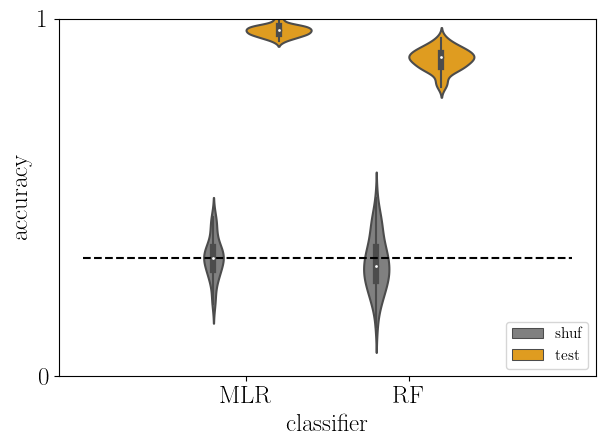

In [27]:
# test versus baseline accuracy
acc2 = acc[np.logical_or(acc['type']=='shuf',acc['type']=='test')]

sb.violinplot(data=acc2, x='clf', y='score', hue='type', hue_order=['shuf','test'], 
              density_norm='width', palette=['gray','orange'])
plt.plot([-1,2], [chance_level]*2, '--k')
plt.yticks([0,1])
plt.xlabel('classifier')
plt.ylabel('accuracy')
plt.ylim(0, 1)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

/tmp/ipykernel_208241/4142835018.py:43: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


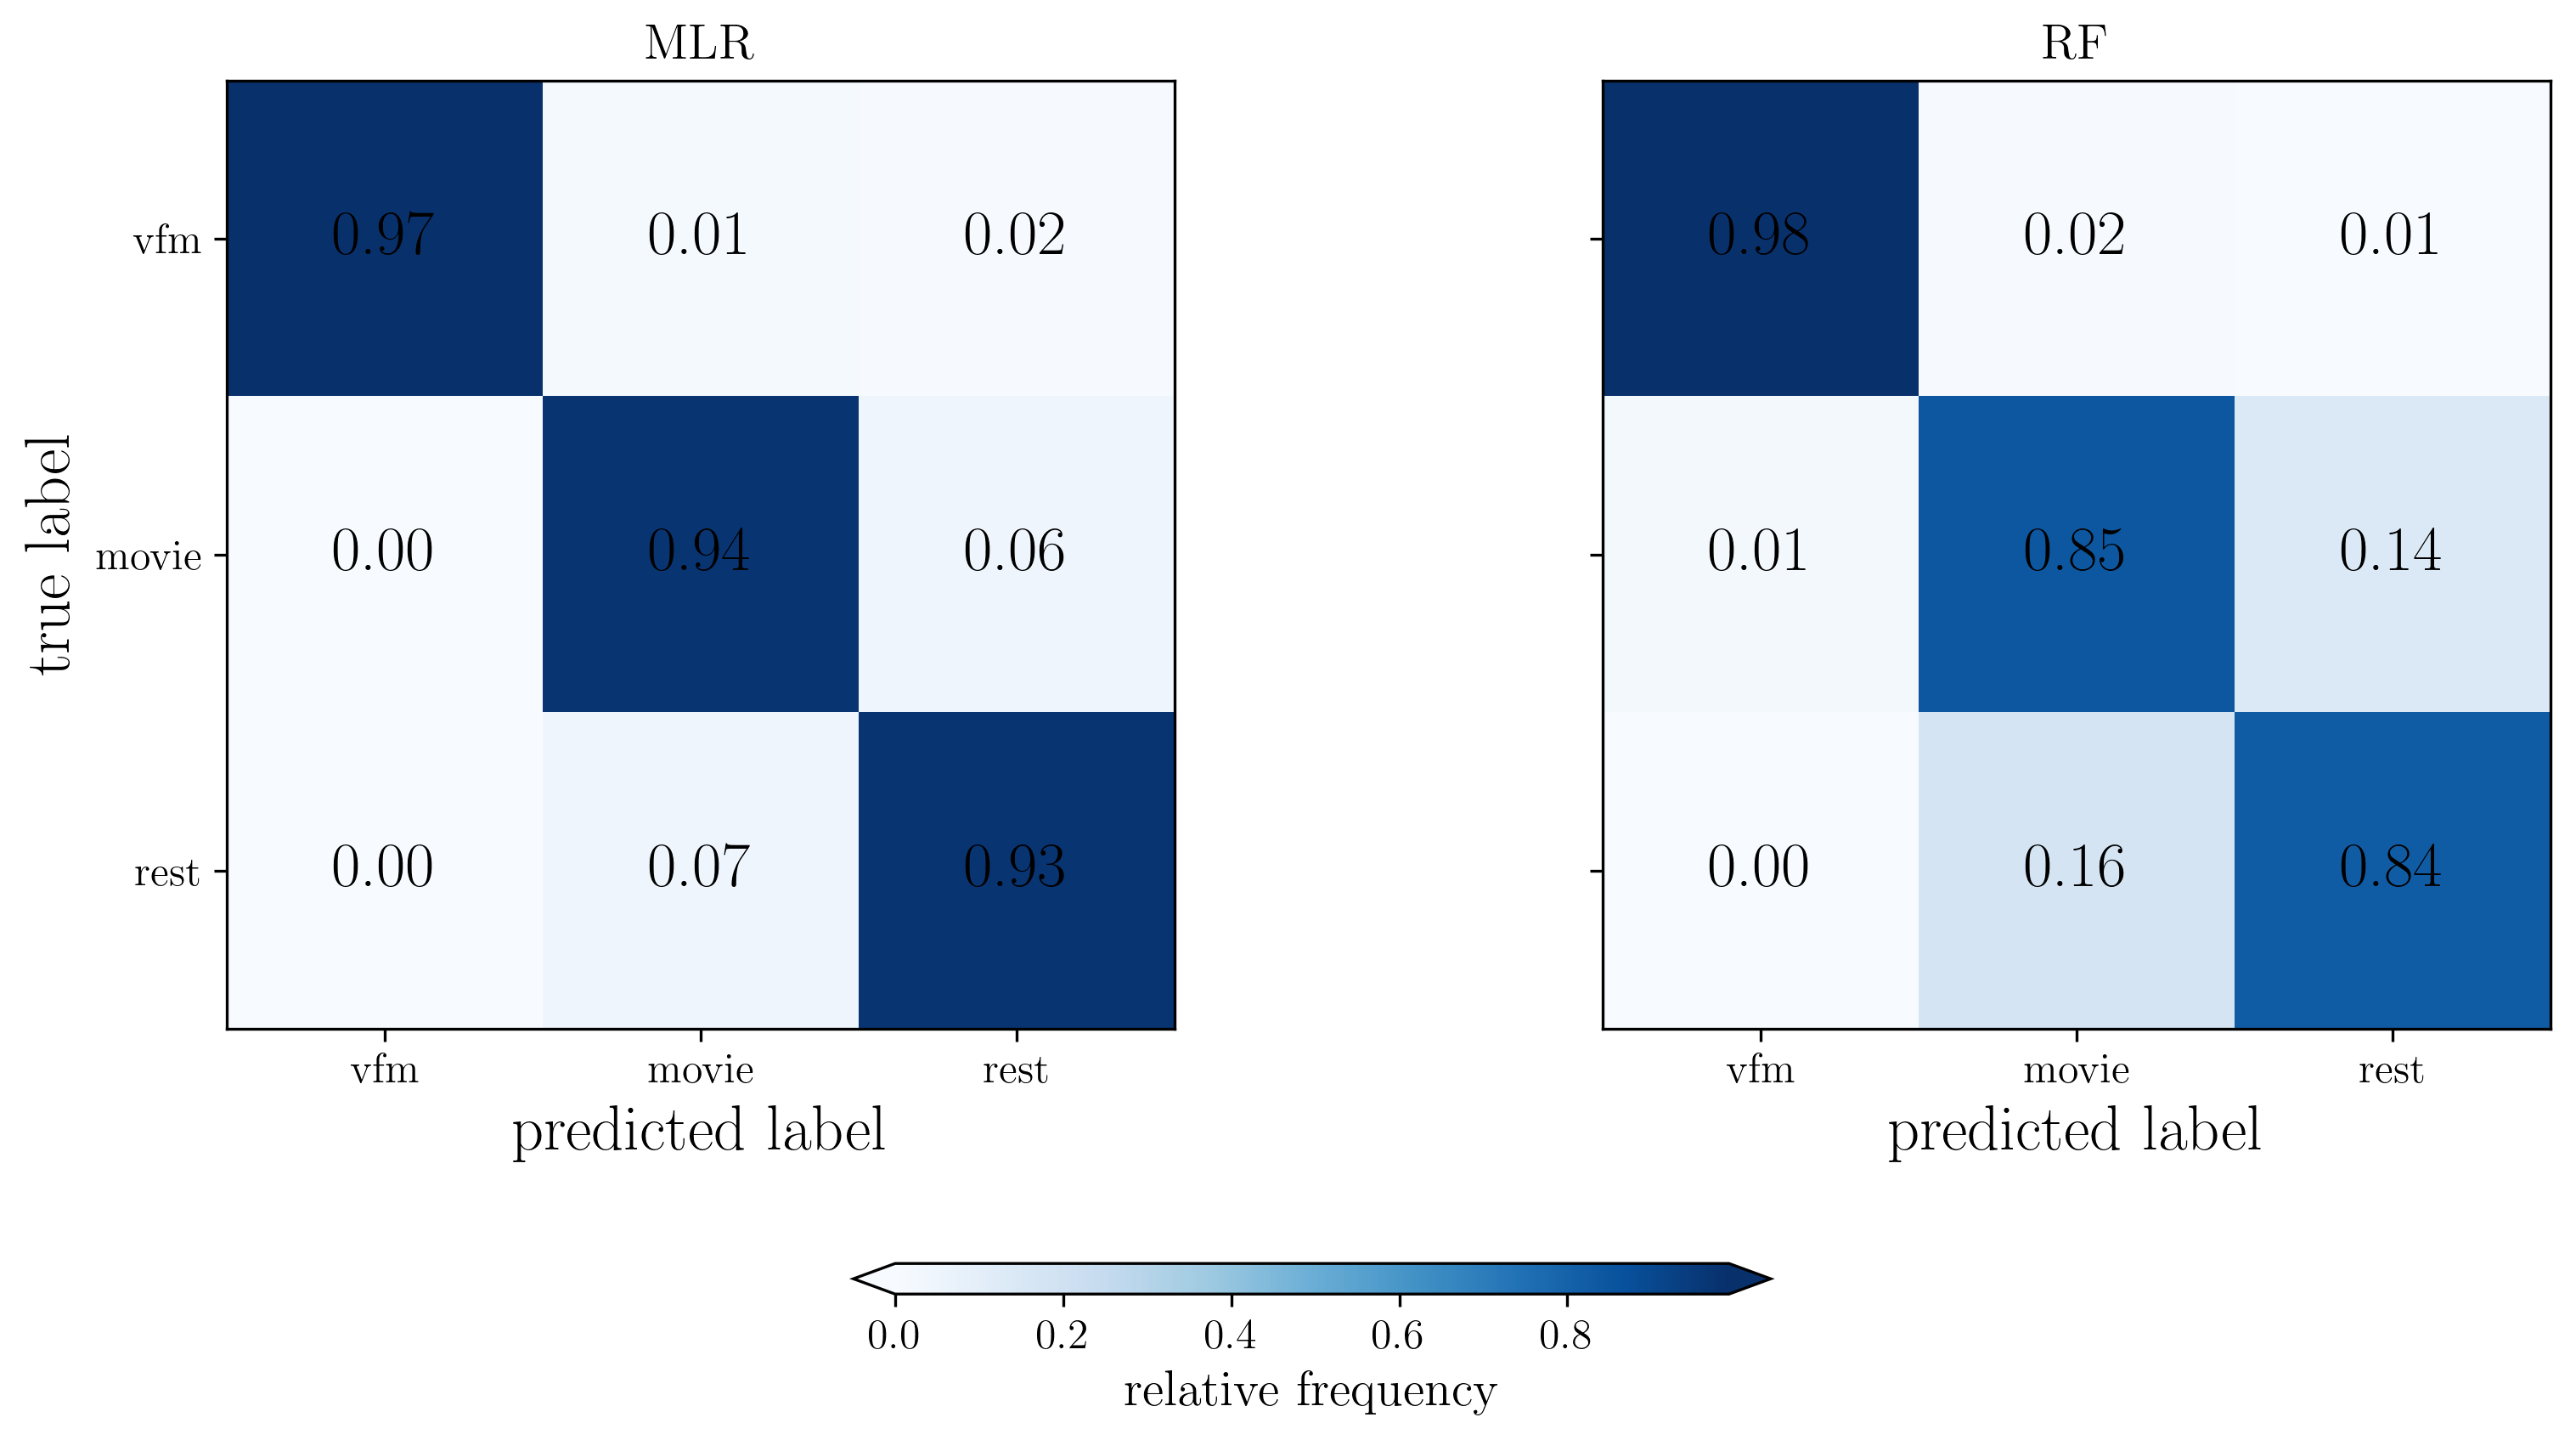

In [28]:
# Normalize confusion matrices
CM_dcm_mlr = CM_dict['MLR'] / np.sum(CM_dict['MLR'], axis=1)[:,np.newaxis]
CM_dcm_rf = CM_dict['RF'] / np.sum(CM_dict['RF'], axis=1)[:,np.newaxis]

fig, ax = plt.subplots(1,2, figsize=(12,5), dpi=300, facecolor="w")

# Plot MLR confusion matrix
im1 = ax[0].imshow(CM_dcm_mlr, cmap='Blues', interpolation='nearest')
ax[0].set_ylabel('true label')
ax[0].set_xlabel('predicted label')
ax[0].set_title('MLR', fontsize=14)
ax[0].set_xticks(range(3), ['vfm','movie','rest'], fontsize=12)
ax[0].set_yticks(range(3), ['vfm','movie','rest'], fontsize=12)

# Add text annotations for MLR
for i in range(3):
    for j in range(3):
        text = ax[0].text(j, i, f'{CM_mou_mlr[i, j]:.2f}',
                         ha="center", va="center", color="black", fontweight='bold')

# Plot RF confusion matrix  
im2 = ax[1].imshow(CM_dcm_rf, cmap='Blues', interpolation='nearest')
ax[1].set_xlabel('predicted label')
ax[1].set_title('RF', fontsize=14)
ax[1].set_xticks(range(3), ['vfm','movie','rest'], fontsize=12)
ax[1].set_yticks(range(3))
labels = [item.get_text() for item in ax[1].get_yticklabels()]
empty_string_labels = ['']*len(labels)
ax[1].set_yticklabels(empty_string_labels)

# Add text annotations for RF
for i in range(3):
    for j in range(3):
        text = ax[1].text(j, i, f'{CM_mou_rf[i, j]:.2f}',
                         ha="center", va="center", color="black", fontweight='bold')

# Add colorbar (moved further down)
cbar = plt.colorbar(im2, cax=fig.add_axes([0.35, -0.05, 0.3, 0.024]), 
                   extend='both', orientation='horizontal')     
cbar.ax.tick_params(labelsize=12)
cbar.set_label('relative frequency', fontsize=14)

plt.tight_layout()

fname = out_pth + 'confMat_MOU_both.svg' 
plt.savefig(fname, transparent=None, dpi='figure', format='svg',
    facecolor='auto', edgecolor='auto', bbox_inches='tight')

plt.show()

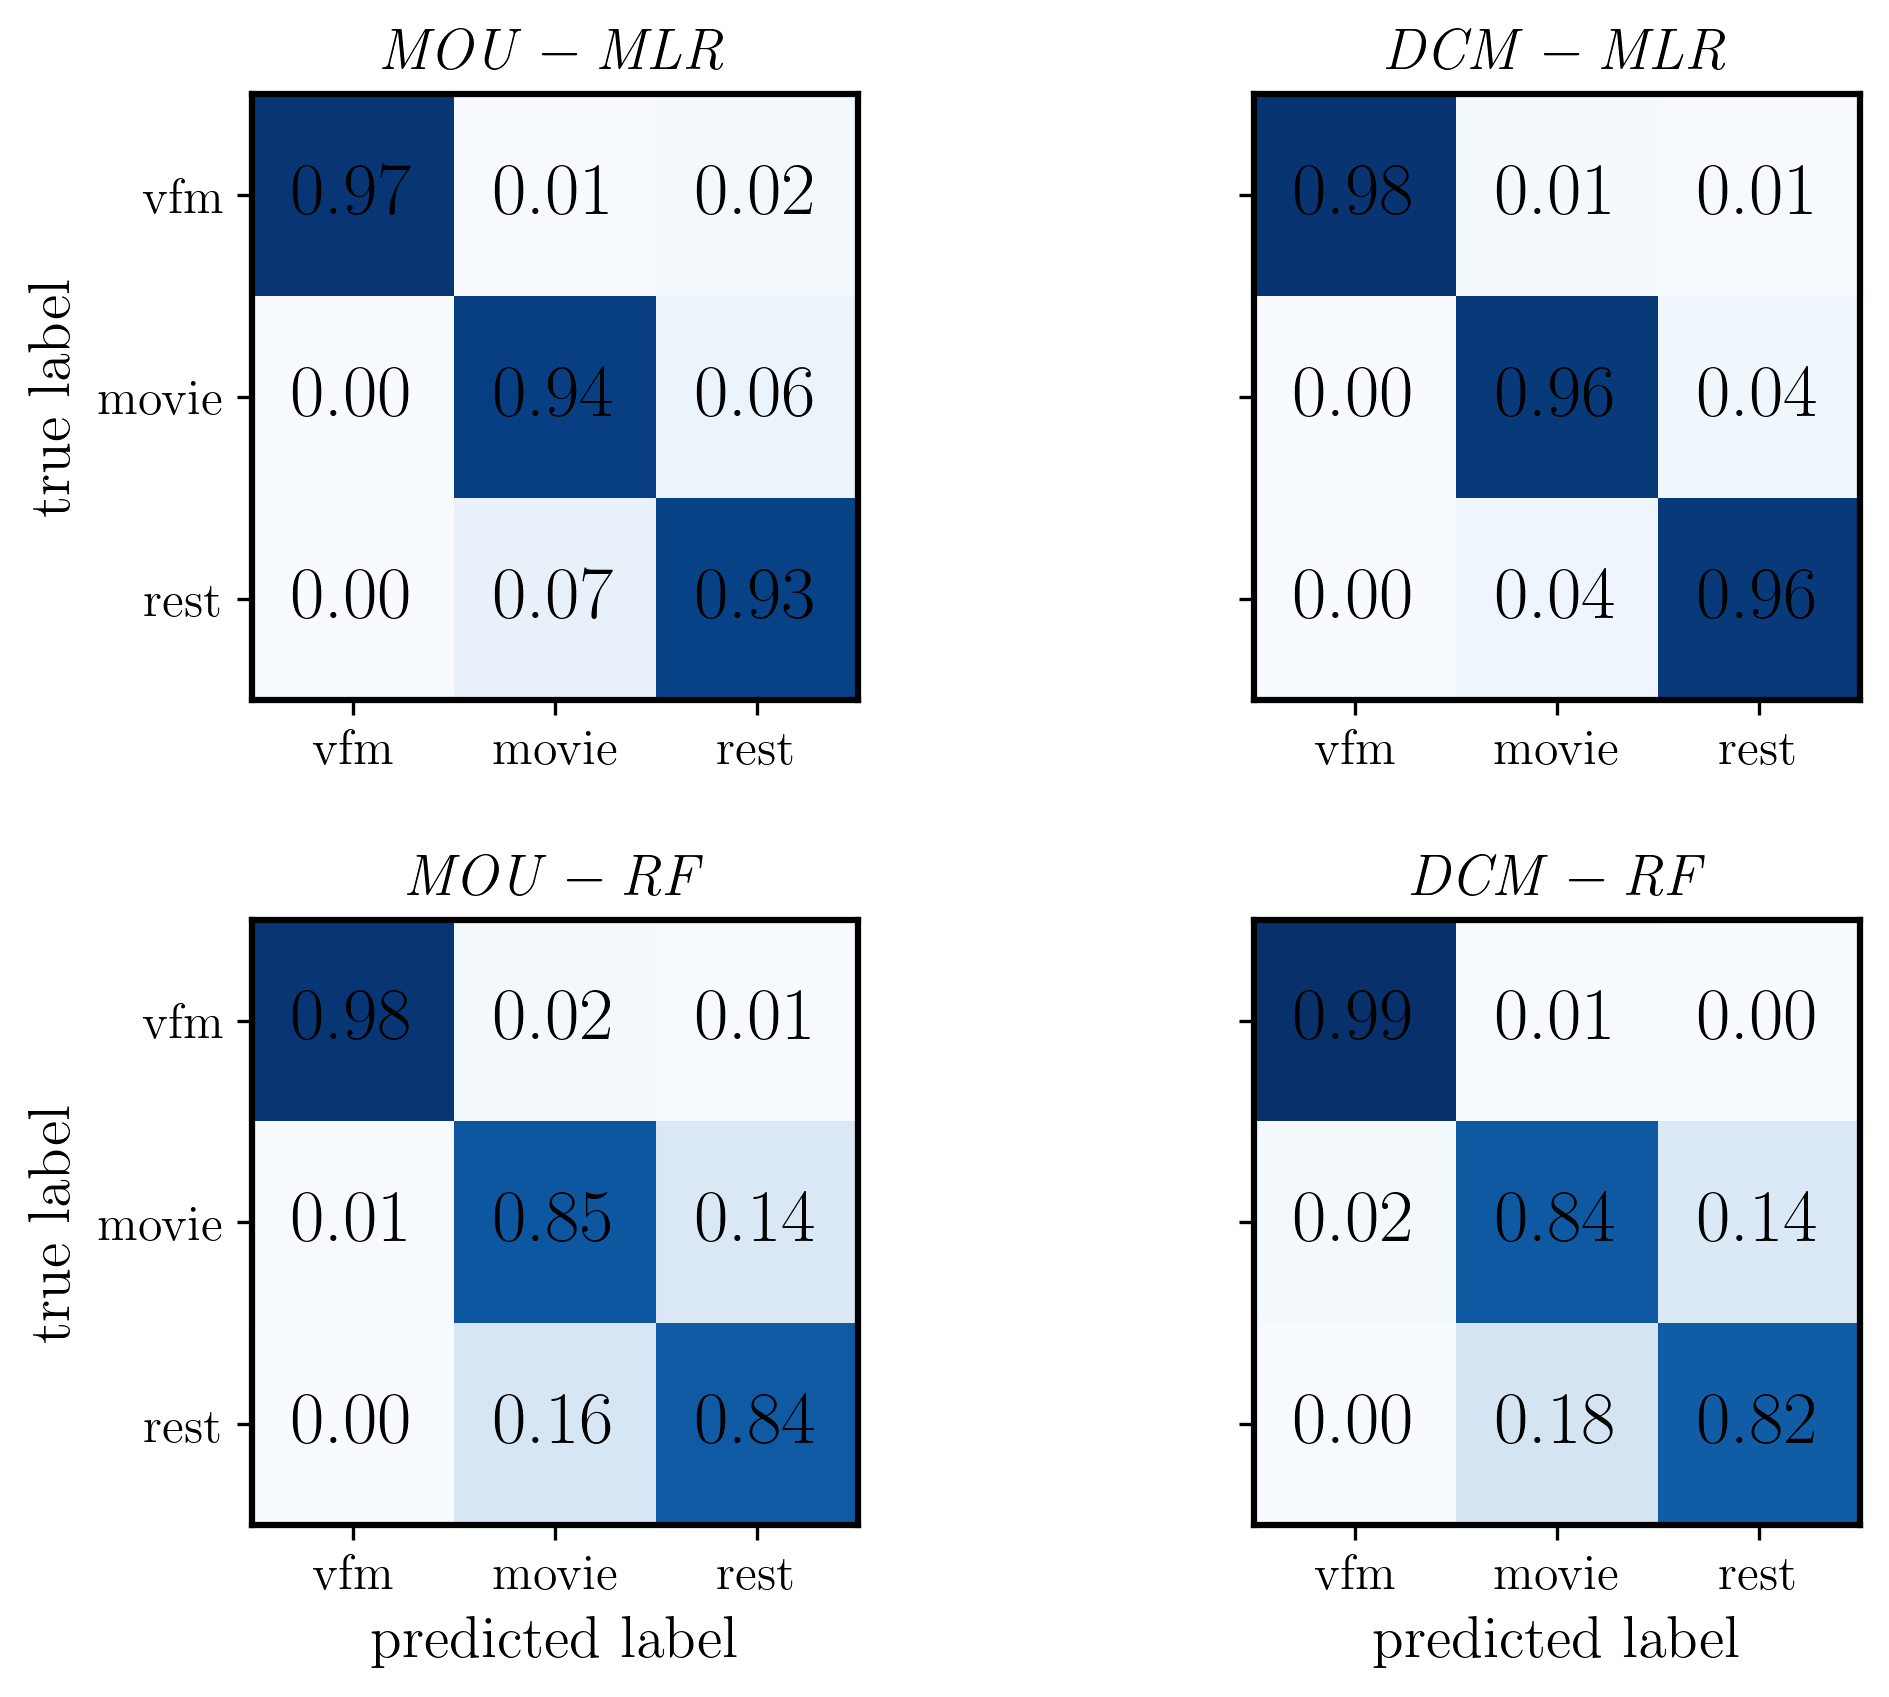

In [29]:
plt.rcParams['text.usetex'] = True
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.family'] = 'serif'

fig, ax = plt.subplots(2, 2, figsize=(8, 6), dpi=300, facecolor="w")

# Top left: MOU MLR
im1 = ax[0,0].imshow(CM_mou_mlr, cmap='Blues', interpolation='nearest', vmin=0, vmax=1)
ax[0,0].set_ylabel('true label', fontsize=14, weight='bold')
ax[0,0].set_title(r'$\mathit{MOU - MLR}$', fontsize=14)
ax[0,0].set_xticks(range(3))
ax[0,0].set_xticklabels(['vfm','movie','rest'], fontsize=12)
ax[0,0].set_yticks(range(3))
ax[0,0].set_yticklabels(['vfm','movie','rest'], fontsize=12)

# Add text annotations for MOU MLR
for i in range(3):
    for j in range(3):
        text = ax[0,0].text(j, i, f'{CM_mou_mlr[i, j]:.2f}',
                           ha="center", va="center", color="black", fontweight='bold')

# Top right: DCM MLR
im2 = ax[0,1].imshow(CM_dcm_mlr, cmap='Blues', interpolation='nearest', vmin=0, vmax=1)
ax[0,1].set_title(r'$\mathit{DCM - MLR}$', fontsize=14)
ax[0,1].set_xticks(range(3))
ax[0,1].set_xticklabels(['vfm','movie','rest'], fontsize=12)
ax[0,1].set_yticks(range(3))
ax[0,1].set_yticklabels([''] * 3)  # Remove y-axis labels

# Add text annotations for DCM MLR
for i in range(3):
    for j in range(3):
        text = ax[0,1].text(j, i, f'{CM_dcm_mlr[i, j]:.2f}',
                           ha="center", va="center", color="black", fontweight='bold')

# Bottom left: MOU RF
im3 = ax[1,0].imshow(CM_mou_rf, cmap='Blues', interpolation='nearest', vmin=0, vmax=1)
ax[1,0].set_ylabel('true label', fontsize=14, weight='bold')
ax[1,0].set_xlabel('predicted label', fontsize=14, weight='bold')
ax[1,0].set_title(r'$\mathit{MOU - RF}$', fontsize=14)
ax[1,0].set_xticks(range(3))
ax[1,0].set_xticklabels(['vfm','movie','rest'], fontsize=12)
ax[1,0].set_yticks(range(3))
ax[1,0].set_yticklabels(['vfm','movie','rest'], fontsize=12)

# Add text annotations for MOU RF
for i in range(3):
    for j in range(3):
        text = ax[1,0].text(j, i, f'{CM_mou_rf[i, j]:.2f}',
                           ha="center", va="center", color="black", fontweight='bold')

# Bottom right: DCM RF
im4 = ax[1,1].imshow(CM_dcm_rf, cmap='Blues', interpolation='nearest', vmin=0, vmax=1)
ax[1,1].set_xlabel('predicted label', fontsize=14, weight='bold')
ax[1,1].set_title(r'$\mathit{DCM - RF}$', fontsize=14)
ax[1,1].set_xticks(range(3))
ax[1,1].set_xticklabels(['vfm','movie','rest'], fontsize=12)
ax[1,1].set_yticks(range(3))
ax[1,1].set_yticklabels([''] * 3)  # Remove y-axis labels

# Add text annotations for DCM RF
for i in range(3):
    for j in range(3):
        text = ax[1,1].text(j, i, f'{CM_dcm_rf[i, j]:.2f}',
                           ha="center", va="center", color="black", fontweight='bold')

# Make frame thicker for all subplots
for i in range(2):
    for j in range(2):
        for spine in ax[i,j].spines.values():
            spine.set_linewidth(1.5)
        ax[i,j].tick_params(labelsize=12)

plt.tight_layout()

fname = out_pth + '/confMat_MOU_DCM_comparison_no_cbar.svg' 
plt.savefig(fname, transparent=None, dpi='figure', format='svg',
    facecolor='auto', edgecolor='auto', bbox_inches='tight')

plt.show()

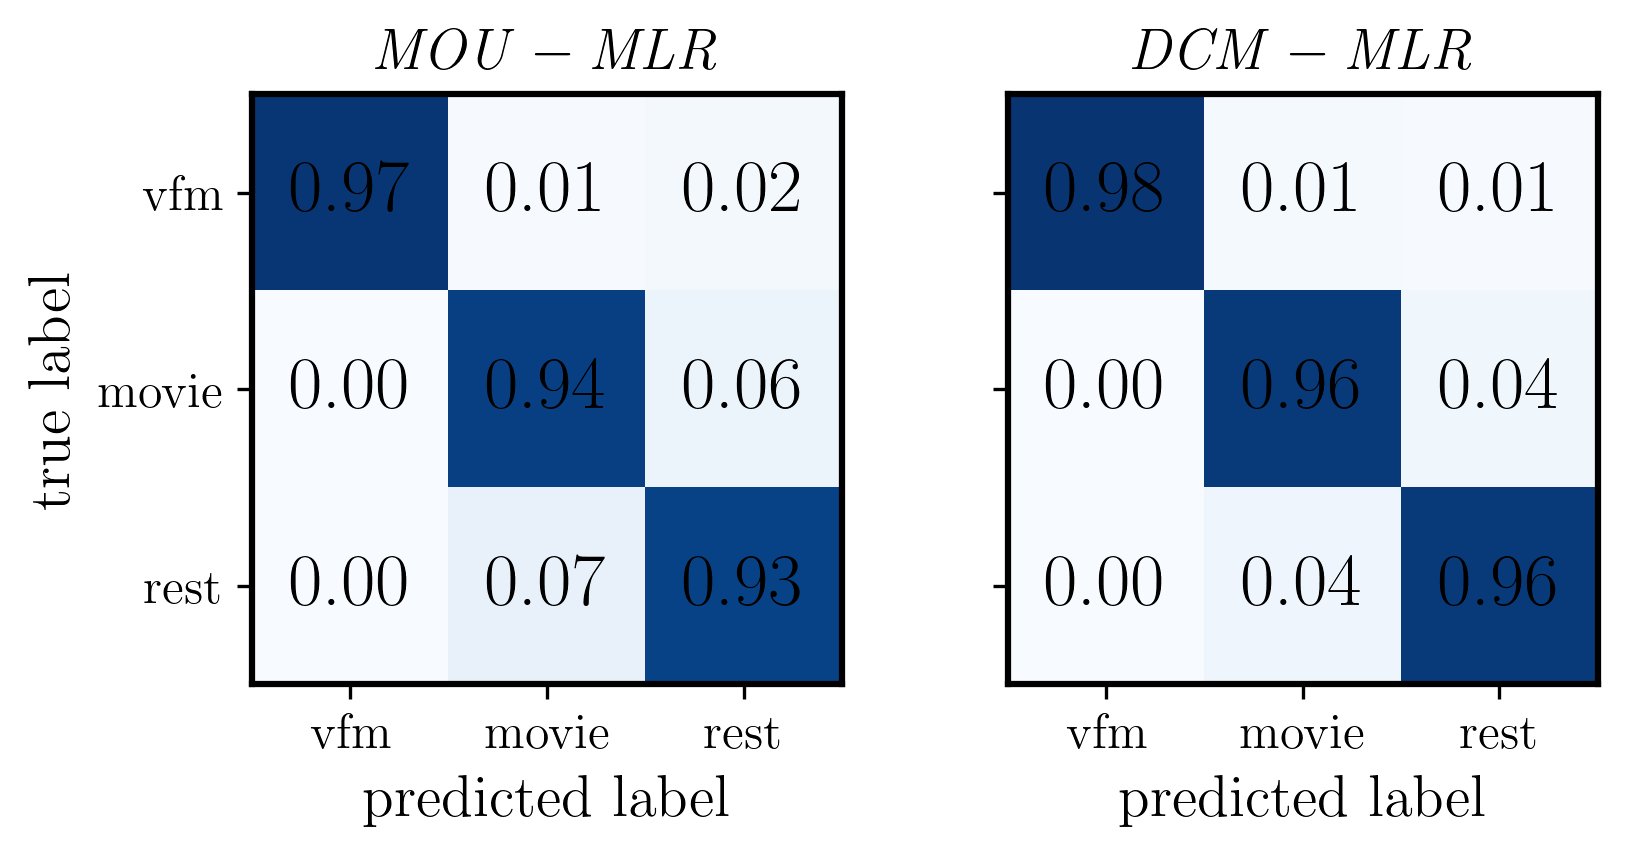

In [30]:
plt.rcParams['text.usetex'] = True
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.family'] = 'serif'

fig, ax = plt.subplots(1, 2, figsize=(6, 3), dpi=300, facecolor="w")  # Changed to 1x2 grid

# Left: MOU MLR
im1 = ax[0].imshow(CM_mou_mlr, cmap='Blues', interpolation='nearest', vmin=0, vmax=1)
ax[0].set_ylabel('true label', fontsize=14, weight='bold')
ax[0].set_xlabel('predicted label', fontsize=14, weight='bold')  # Added xlabel
ax[0].set_title(r'$\mathit{MOU - MLR}$', fontsize=14)
ax[0].set_xticks(range(3))
ax[0].set_xticklabels(['vfm','movie','rest'], fontsize=12)
ax[0].set_yticks(range(3))
ax[0].set_yticklabels(['vfm','movie','rest'], fontsize=12)

# Add text annotations for MOU MLR
for i in range(3):
    for j in range(3):
        text = ax[0].text(j, i, f'{CM_mou_mlr[i, j]:.2f}',
                           ha="center", va="center", color="black", fontweight='bold')

# Right: DCM MLR
im2 = ax[1].imshow(CM_dcm_mlr, cmap='Blues', interpolation='nearest', vmin=0, vmax=1)
ax[1].set_xlabel('predicted label', fontsize=14, weight='bold')  # Added xlabel
ax[1].set_title(r'$\mathit{DCM - MLR}$', fontsize=14)
ax[1].set_xticks(range(3))
ax[1].set_xticklabels(['vfm','movie','rest'], fontsize=12)
ax[1].set_yticks(range(3))
ax[1].set_yticklabels([''] * 3)  # Remove y-axis labels

# Add text annotations for DCM MLR
for i in range(3):
    for j in range(3):
        text = ax[1].text(j, i, f'{CM_dcm_mlr[i, j]:.2f}',
                           ha="center", va="center", color="black", fontweight='bold')

# Make frame thicker for all subplots
for i in range(2):
    for spine in ax[i].spines.values():
        spine.set_linewidth(1.5)
    ax[i].tick_params(labelsize=12)

plt.tight_layout()

fname = out_pth + '/confMat_MOU_DCM_comparison_no_cbar.svg' 
plt.savefig(fname, transparent=None, dpi='figure', format='svg',
    facecolor='auto', edgecolor='auto', bbox_inches='tight')

plt.show()

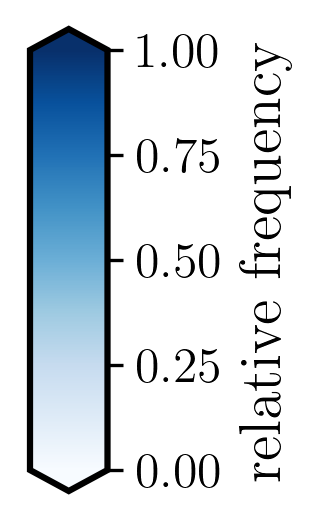

In [32]:
import matplotlib.colorbar as cbar
import matplotlib.colors as mcolors

# Set font configuration to match the main figure
plt.rcParams['text.usetex'] = True
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.family'] = 'serif'

# Create a standalone figure for the colorbar
fig, ax = plt.subplots(figsize=(1/3, 6/3), dpi=300, facecolor="w")  # Narrow and tall for vertical bar

# Create a dummy colormap and normalization to match the main figure
cmap = plt.cm.Blues
norm = mcolors.Normalize(vmin=0, vmax=1)

# Create the colorbar using ColorbarBase
cb = cbar.ColorbarBase(ax, cmap=cmap, norm=norm, orientation='vertical', extend='both')
cb.ax.tick_params(labelsize=12)  # Match tick font size
cb.set_label('relative frequency', fontsize=14, weight='bold')  # Match label font size and weight

# Add edges (border) to the colorbar for scientific paper style
ax.set_frame_on(True)
for spine in ax.spines.values():
    spine.set_linewidth(1.5)  # Match the frame thickness from the main figure

# Save the standalone colorbar figure
fname = out_pth + '/standalone_colorbar_with_edges.svg'
plt.savefig(fname, transparent=None, dpi='figure', format='svg',
    facecolor='auto', edgecolor='auto', bbox_inches='tight')

plt.show()

In [31]:
out_pth

'/media/nicolas/KINGSTON/retNet_final/output'

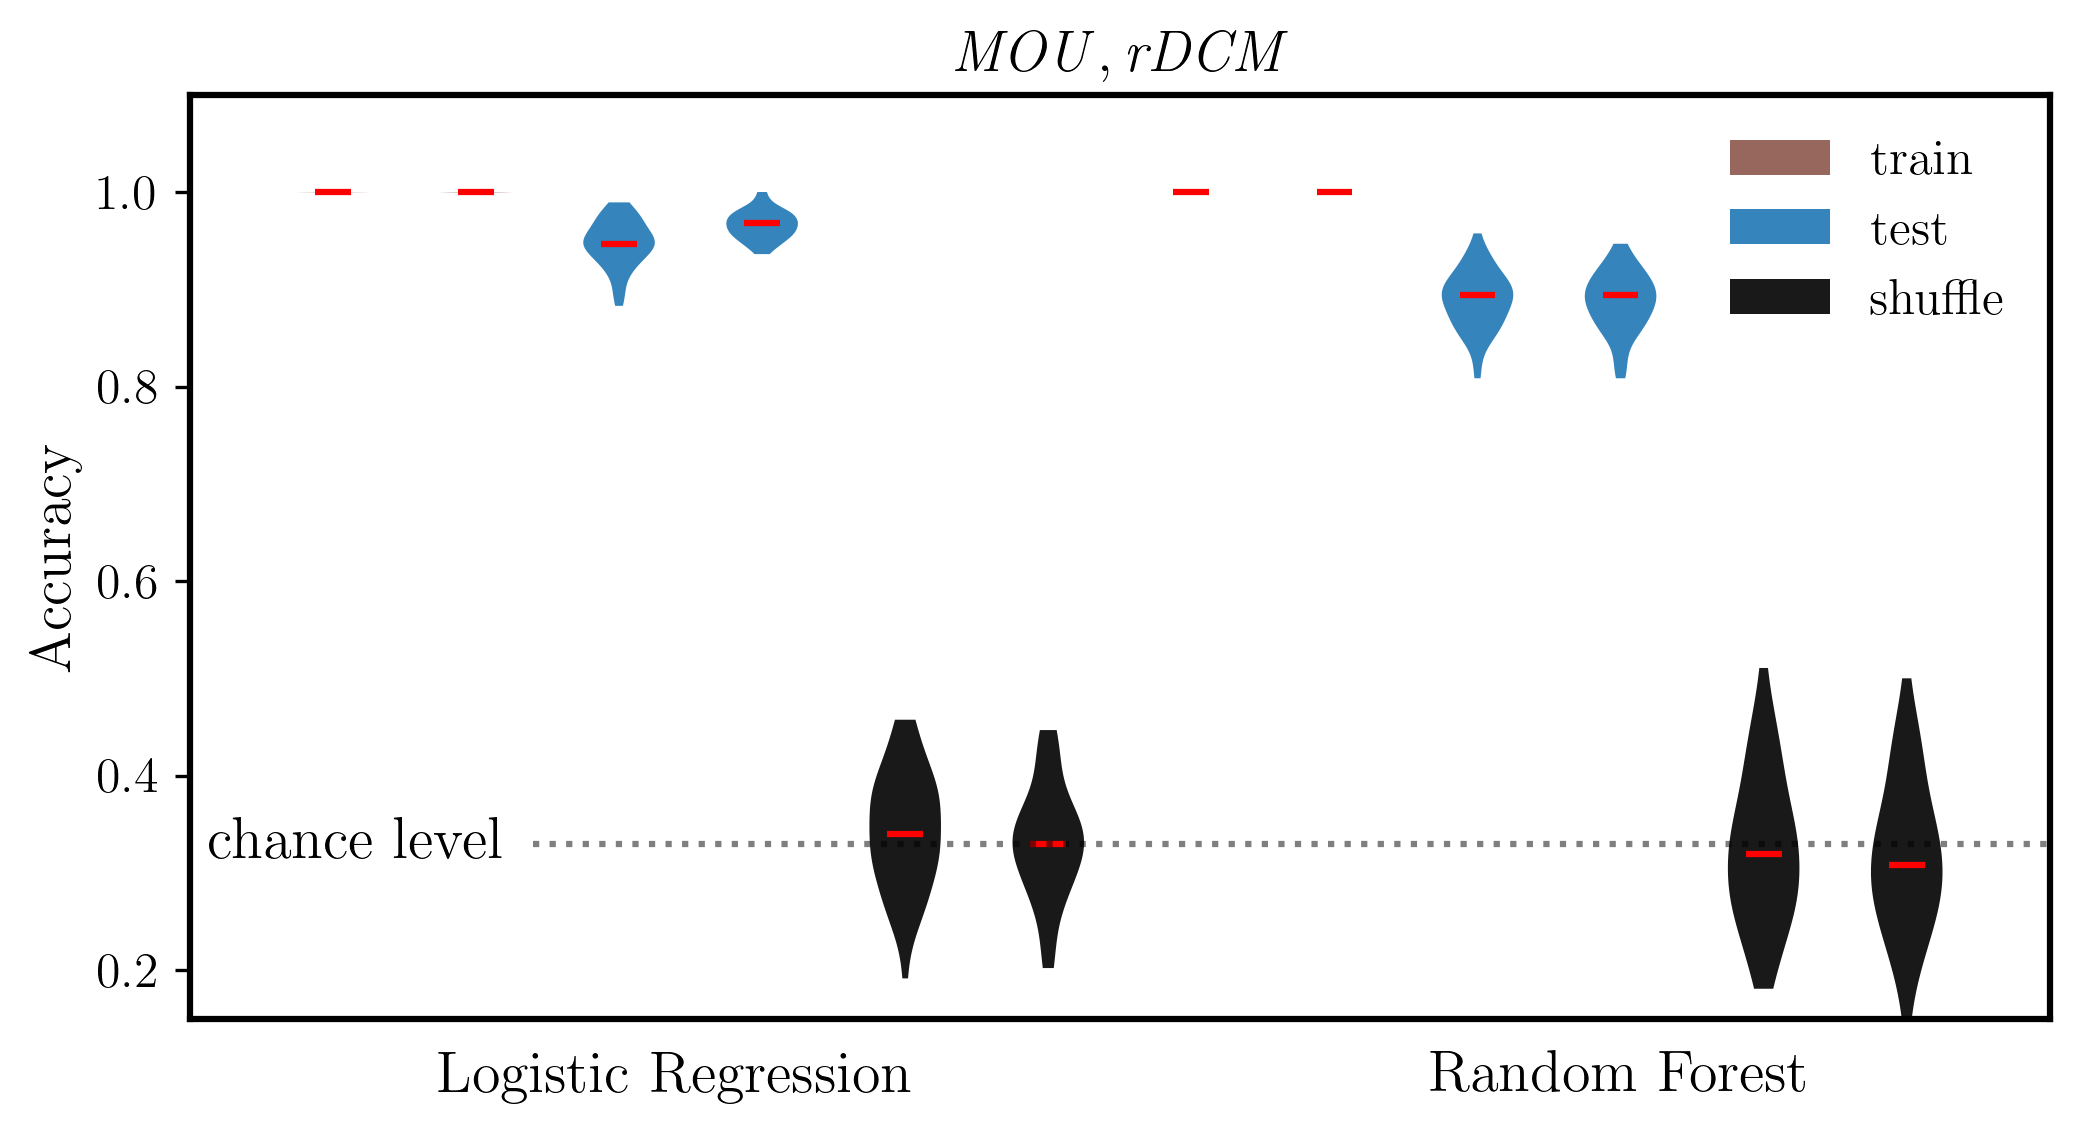

In [ ]:
# Interleave the arrays
combined_condition = np.empty((dist_mou.shape[0] + dist_dcm.shape[0], dist_mou.shape[1]), dtype=dist_mou.dtype)
combined_condition[0::2, :] = dist_mou
combined_condition[1::2, :] = dist_dcm

labels = ['',
        '$\mathbf{MLR}_{train}$',
        '',
        '$\mathbf{MLR}_{test}$',
        '',
        '$\mathbf{MLR}_{shuffle}$',
        '',
        '$\mathbf{RF}_{train}$', 
        '',
        '$\mathbf{RF}_{test}$',
        '',
        '$\mathbf{RF}_{shuffle}$',
        '']

colors = ['C5','C5','C0','C0','Black','Black','C5','C5','C0','C0','Black','Black']

fig, ax = plt.subplots(figsize=(8, 4), dpi=300, facecolor="w")


plt.rcParams['text.usetex'] = True
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.family'] = 'serif'

# Model fit
plots = ax.violinplot(combined_condition.T, vert=True, showmedians=True, showextrema=False, widths=0.5, points=100, bw_method=0.5)    
# Set the color of the violin patches
for pc, color in zip(plots['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.9)
# Set median markers to red
plots['cmedians'].set_colors(['red'] * len(plots['cmedians'].get_segments()))

ax.set_ylabel('Accuracy', fontsize=14,weight='bold')
ax.set_title(r'$\mathit{MOU, rDCM}$', fontsize=14)
ax.set_ylim(0.15, 1.1)
ax.tick_params(axis='y', labelsize=12)

# Chance level line with label
ax.plot([2.4, 13], [chance_level]*2, ':k',alpha=0.5)
ax.text(2.2, chance_level, 'chance level', fontsize=14, va='center', ha='right')

ax.set_xlim(0, 13)
# Remove x ticks and labels
ax.set_xticks([])

# Add classifier labels at the bottom
ax.text(3.4, 0.075, 'Logistic Regression', fontsize=14,weight='bold', ha='center', transform=ax.transData)
ax.text(10, 0.075, 'Random Forest', fontsize=14,weight='bold', ha='center', transform=ax.transData)

# Make frame thicker
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# Add legend with no bounding box
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='C5', alpha=0.9, label='train'),
                   Patch(facecolor='C0', alpha=0.9, label='test'),
                   Patch(facecolor='Black', alpha=0.9, label='shuffle')]
ax.legend(handles=legend_elements, loc='upper right', fontsize=12, frameon=False)

fname = out_pth + 'ovrFit_MOU.svg' 
plt.savefig(fname, transparent=None, dpi='figure', format='svg',
    facecolor='auto', edgecolor='auto', bbox_inches='tight')

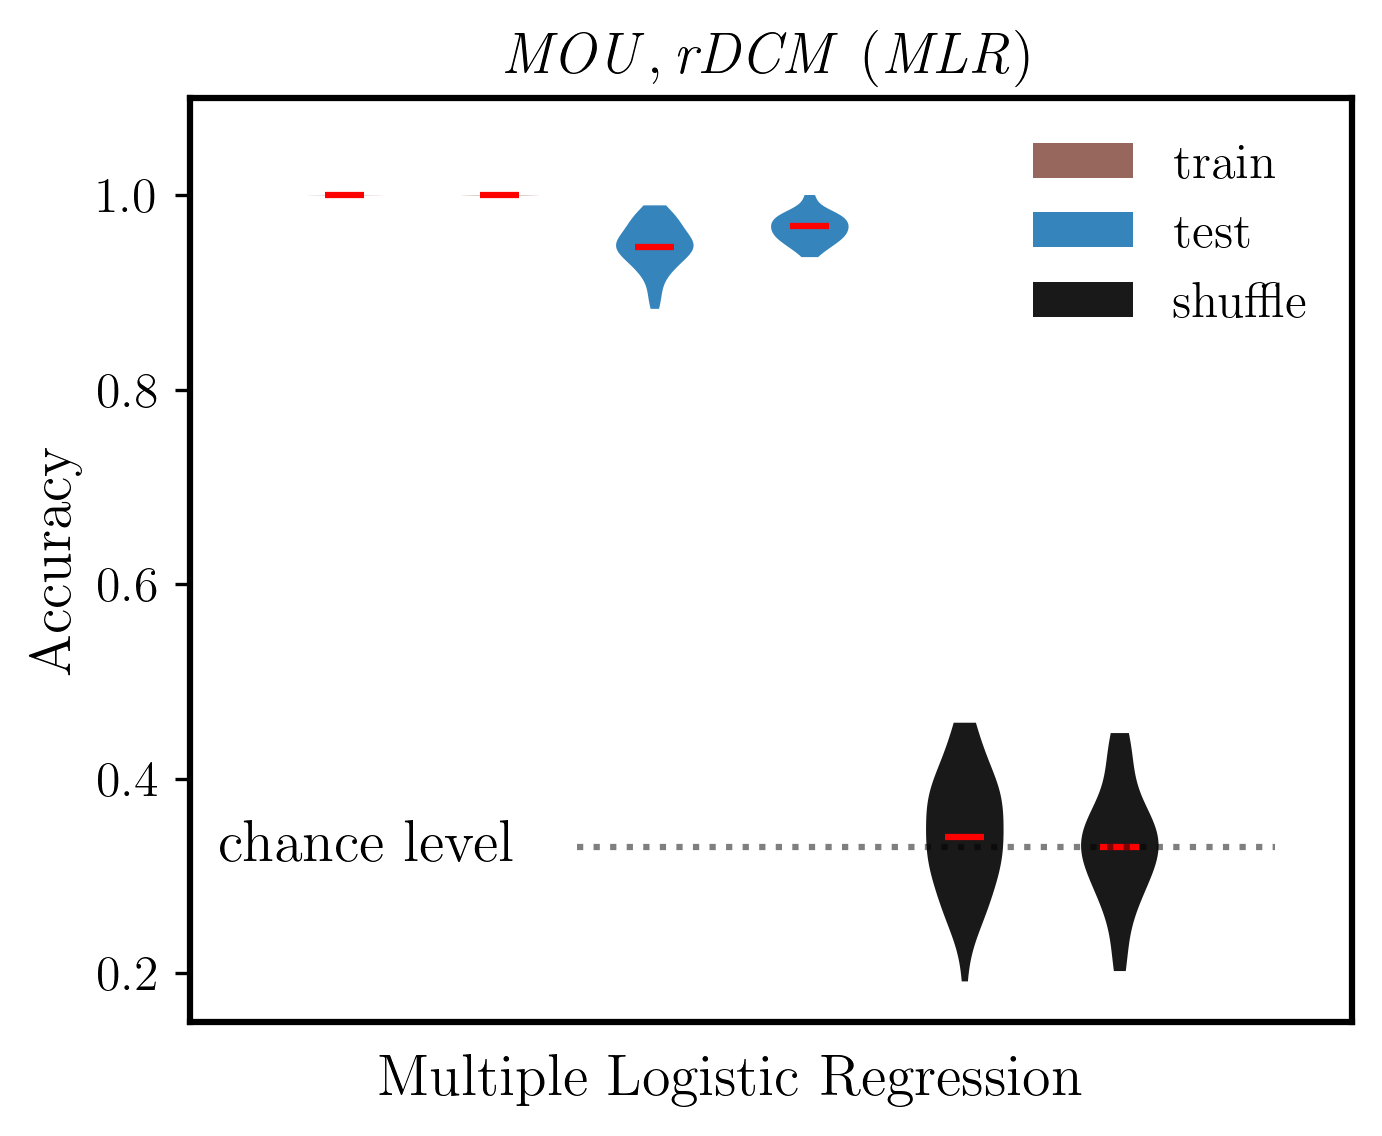

In [68]:
# Extract only MLR results (first 3 rows from each: train, test, shuffle)
# dist_mou and dist_dcm have shape (6, n_splits): [mlr_train, mlr_test, mlr_shuffle, rf_train, rf_test, rf_shuffle]
mlr_mou = dist_mou[:3, :]  # MLR train, test, shuffle for MOU
mlr_dcm = dist_dcm[:3, :]  # MLR train, test, shuffle for DCM

# Interleave the arrays (MOU and DCM alternating)
combined_mlr = np.empty((mlr_mou.shape[0] + mlr_dcm.shape[0], mlr_mou.shape[1]), dtype=mlr_mou.dtype)
combined_mlr[0::2, :] = mlr_mou
combined_mlr[1::2, :] = mlr_dcm

colors = ['C5', 'C5', 'C0', 'C0', 'Black', 'Black']

fig, ax = plt.subplots(figsize=(5, 4), dpi=300, facecolor="w")

plt.rcParams['text.usetex'] = True
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.family'] = 'serif'

# Model fit
plots = ax.violinplot(combined_mlr.T, vert=True, showmedians=True, showextrema=False, 
                      widths=0.5, points=100, bw_method=0.5)

# Set the color of the violin patches
for pc, color in zip(plots['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.9)

# Set median markers to red
plots['cmedians'].set_colors(['red'] * len(plots['cmedians'].get_segments()))

ax.set_ylabel('Accuracy', fontsize=14, weight='bold')
ax.set_title(r'$\mathit{MOU, rDCM\ (MLR)}$', fontsize=14)
ax.set_ylim(0.15, 1.1)
ax.tick_params(axis='y', labelsize=12)

# Chance level line with label
ax.plot([2.5, 7], [chance_level]*2, ':k', alpha=0.5)
ax.text(2.1, chance_level, 'chance level', fontsize=14, va='center', ha='right')

ax.set_xlim(0, 7.5)
# Remove x ticks and labels
ax.set_xticks([])

# Add label at the bottom
ax.text(3.5, 0.075, 'Multiple Logistic Regression', fontsize=14, weight='bold', ha='center', transform=ax.transData)

# Make frame thicker
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# Add legend with no bounding box
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='C5', alpha=0.9, label='train'),
                   Patch(facecolor='C0', alpha=0.9, label='test'),
                   Patch(facecolor='Black', alpha=0.9, label='shuffle')]
ax.legend(handles=legend_elements, loc='upper right', fontsize=12, frameon=False)

fname = out_pth + '/ovrFit_MLR_only.svg' 
plt.savefig(fname, transparent=None, dpi='figure', format='svg',
    facecolor='auto', edgecolor='auto', bbox_inches='tight')

plt.show()

## Cross-decoding between MOU and rDCM

Alignment between MOU and rDCM through cross learning.

In [45]:
# cross learning
from sklearn.preprocessing import MinMaxScaler
X_ref = MinMaxScaler().fit_transform(X_dcm)
X_tgt = MinMaxScaler().fit_transform(X_mou)
# to store result accuracies
acc = pd.DataFrame()
CM = np.zeros((3,3))

# loop over classifiers
for i, (k, param_name) in enumerate(zip(dict_clf,dict_params)):
    # get classifier and related information
    clf = dict_clf[k]
    param_vals = dict_params[param_name]
    # print(param_name, param_vals)

    # repeat classification
    for train_ind, test_ind in cvs.split(X_ref, y, groups=gp_sub):
        # grid search for hyperparameter C
        gscv = GridSearchCV(clf,
                    {param_name: param_vals},
                    cv=cv_nest)
        gscv.fit(X_ref[train_ind,:], y[train_ind])
        best_clf = gscv.best_estimator_
        print(gscv.best_params_)

        # train and test best classifier with subject labels
        best_clf.fit(X_ref[train_ind,:], y[train_ind])
        # accuracies
        d = {'type': ['ref'],
             'clf': [k], 
             'score': [best_clf.score(X_ref[test_ind,:], y[test_ind])]}
        acc = pd.concat((acc, pd.DataFrame(data=d)), ignore_index=True)
        d = {'type': ['tgt'],
             'clf': [k], 
             'score': [best_clf.score(X_tgt[test_ind,:], y[test_ind])]}
        acc = pd.concat((acc, pd.DataFrame(data=d)), ignore_index=True)

        CM += confusion_matrix(y[test_ind], best_clf.predict(X_tgt[test_ind,:]))

        # shuffling labels and fit again for evaluation of chance level
        train_ind_rand = np.random.permutation(train_ind)
        best_clf.fit(X_ref[train_ind,:], y[train_ind_rand])
        d = {'type': ['shuf'],
             'clf': [k], 
             'score': [best_clf.score(X_tgt[test_ind,:], y[test_ind])]}
        acc = pd.concat((acc, pd.DataFrame(data=d)), ignore_index=True)



{'C': 10.0}


/home/nicolas/anaconda3/envs/lamidec/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'C': 100.0}


/home/nicolas/anaconda3/envs/lamidec/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'C': 1.0}
{'C': 100.0}


...

{'C': 100.0}


/home/nicolas/anaconda3/envs/lamidec/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'C': 1.0}
{'C': 1.0}
{'C': 10.0}


/home/nicolas/anaconda3/envs/lamidec/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 50}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimat

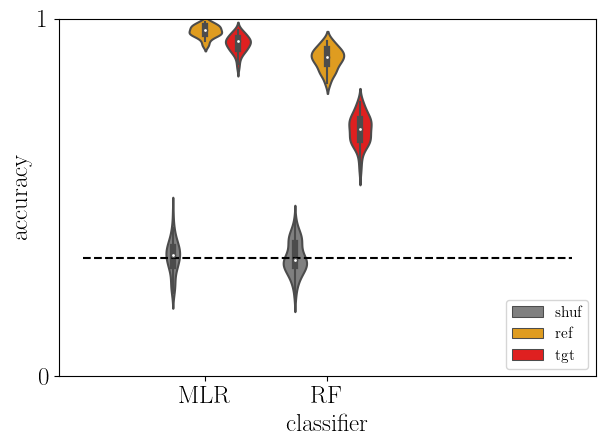

In [46]:
# plot
sb.violinplot(data=acc, x='clf', y='score', hue='type', hue_order=['shuf','ref', 'tgt'], 
              density_norm='width', palette=['gray','orange','red'])
plt.plot([-1,3], [chance_level]*2, '--k')
plt.yticks([0,1])
plt.xlabel('classifier')
plt.ylabel('accuracy')
plt.ylim(0, 1)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()



acc_dcm2mou = acc

In [47]:
# cross learning
X_ref = MinMaxScaler().fit_transform(X_mou)
X_tgt = MinMaxScaler().fit_transform(X_dcm)
# to store result accuracies
acc = pd.DataFrame()
CM = np.zeros((3,3))

# loop over classifiers
for i, (k, param_name) in enumerate(zip(dict_clf,dict_params)):
    # get classifier and related information
    clf = dict_clf[k]
    param_vals = dict_params[param_name]
    # print(param_name, param_vals)

    # repeat classification
    for train_ind, test_ind in cvs.split(X_ref, y, groups=gp_sub):
        # grid search for hyperparameter C
        gscv = GridSearchCV(clf,
                    {param_name: param_vals},
                    cv=cv_nest)
        gscv.fit(X_ref[train_ind,:], y[train_ind])
        best_clf = gscv.best_estimator_
        print(gscv.best_params_)

        # train and test best classifier with subject labels
        best_clf.fit(X_ref[train_ind,:], y[train_ind])
        # accuracies
        d = {'type': ['ref'],
             'clf': [k], 
             'score': [best_clf.score(X_ref[test_ind,:], y[test_ind])]}
        acc = pd.concat((acc, pd.DataFrame(data=d)), ignore_index=True)
        d = {'type': ['tgt'],
             'clf': [k], 
             'score': [best_clf.score(X_tgt[test_ind,:], y[test_ind])]}
        acc = pd.concat((acc, pd.DataFrame(data=d)), ignore_index=True)

        CM += confusion_matrix(y[test_ind], best_clf.predict(X_tgt[test_ind,:]))

        # shuffling labels and fit again for evaluation of chance level
        train_ind_rand = np.random.permutation(train_ind)
        best_clf.fit(X_ref[train_ind,:], y[train_ind_rand])
        d = {'type': ['shuf'],
             'clf': [k], 
             'score': [best_clf.score(X_tgt[test_ind,:], y[test_ind])]}
        acc = pd.concat((acc, pd.DataFrame(data=d)), ignore_index=True)



{'C': 1.0}
{'C': 1.0}
{'C': 100.0}


/home/nicolas/anaconda3/envs/lamidec/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'C': 1.0}
{'C': 1.0}
{'C': 1.0}
{'C': 10.0}
{'C': 10.0}
{'C': 1.0}
{'C': 1.0}
{'C': 10.0}
{'C': 10.0}
{'C': 100.0}


/home/nicolas/anaconda3/envs/lamidec/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'C': 100.0}


...

{'C': 10.0}


/home/nicolas/anaconda3/envs/lamidec/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'C': 1.0}
{'C': 100.0}


/home/nicolas/anaconda3/envs/lamidec/lib/python3.8/site-packages/sklearn/linear_model/_logistic.py:460: ConvergenceWarning: lbfgs failed to converge (status=1):
STOP: TOTAL NO. of ITERATIONS REACHED LIMIT.

Increase the number of iterations (max_iter) or scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


{'C': 1.0}
{'C': 10.0}
{'C': 1.0}
{'C': 1.0}
{'C': 10.0}
{'C': 1.0}
{'C': 1.0}
{'C': 10.0}
{'C': 1.0}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 100}
{'n_estimators': 50}
{'n_estimators': 10

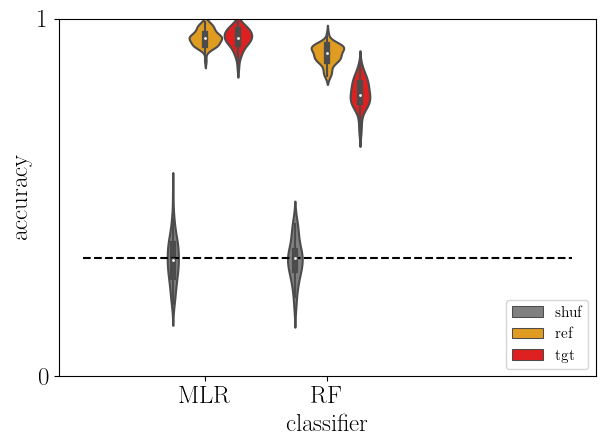

In [48]:
# plot

sb.violinplot(data=acc, x='clf', y='score', hue='type', hue_order=['shuf','ref', 'tgt'], 
              density_norm='width', palette=['gray','orange','red'])
plt.plot([-1,3], [chance_level]*2, '--k')
plt.yticks([0,1])
plt.xlabel('classifier')
plt.ylabel('accuracy')
plt.ylim(0, 1)
plt.legend(loc='lower right', fontsize=11)
plt.tight_layout()
plt.show()

acc_mou2dcm = acc

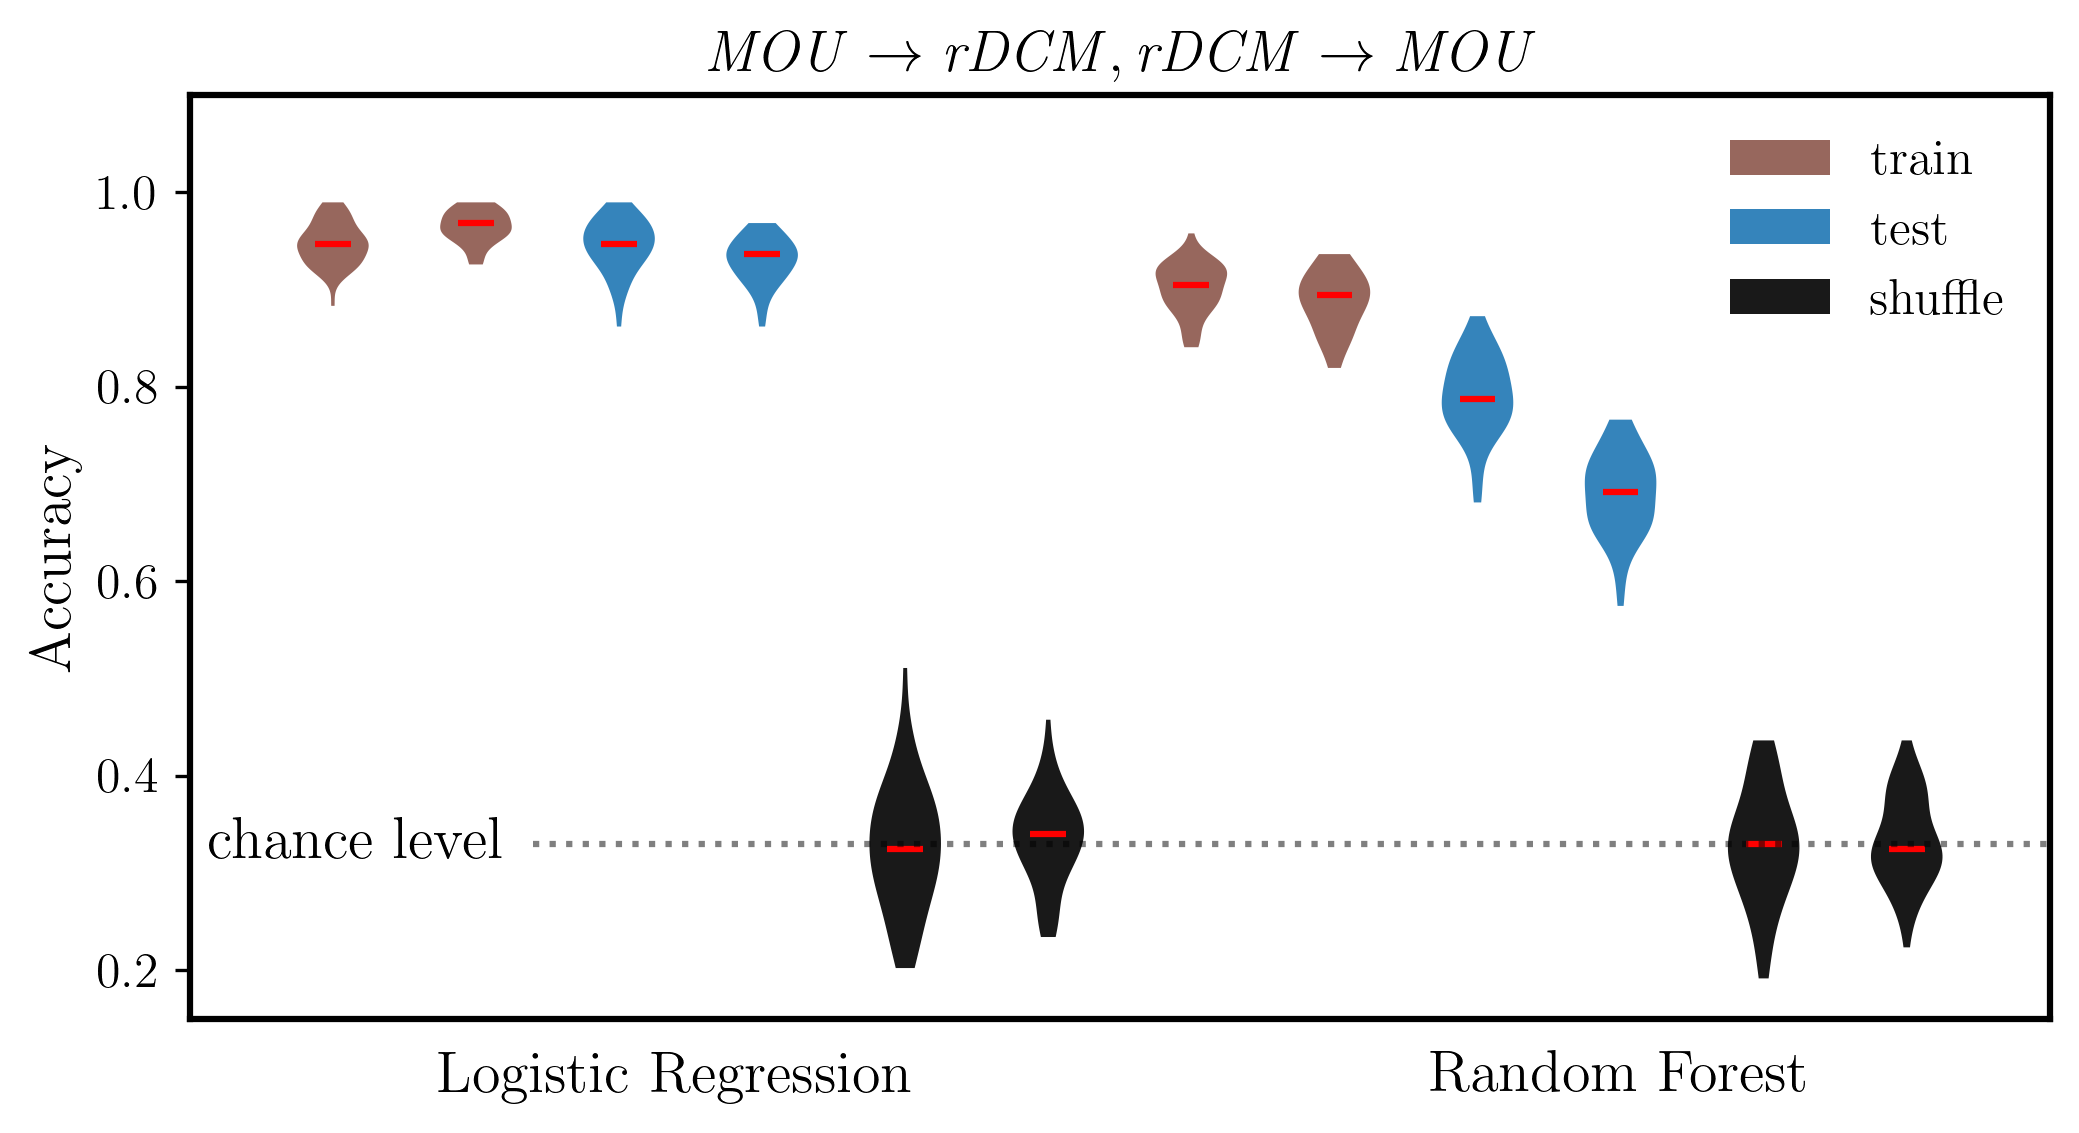

In [49]:
acc = acc_mou2dcm

mlr_train = acc[(acc['type'] == 'ref') & (acc['clf'] == 'MLR')]
mlr_test = acc[(acc['type'] == 'tgt') & (acc['clf'] == 'MLR')]
mlr_shuffle = acc[(acc['type'] == 'shuf') & (acc['clf'] == 'MLR')]

rf_train = acc[(acc['type'] == 'ref') & (acc['clf'] == 'RF')]  
rf_test = acc[(acc['type'] == 'tgt') & (acc['clf'] == 'RF')]    
rf_shuffle = acc[(acc['type'] == 'shuf') & (acc['clf'] == 'RF')]

dist_mou2dcm = np.vstack((mlr_train['score'], mlr_test['score'], mlr_shuffle['score'], rf_train['score'], rf_test['score'], rf_shuffle['score']))

acc = acc_dcm2mou

mlr_train = acc[(acc['type'] == 'ref') & (acc['clf'] == 'MLR')]
mlr_test = acc[(acc['type'] == 'tgt') & (acc['clf'] == 'MLR')]
mlr_shuffle = acc[(acc['type'] == 'shuf') & (acc['clf'] == 'MLR')]

rf_train = acc[(acc['type'] == 'ref') & (acc['clf'] == 'RF')]  
rf_test = acc[(acc['type'] == 'tgt') & (acc['clf'] == 'RF')]    
rf_shuffle = acc[(acc['type'] == 'shuf') & (acc['clf'] == 'RF')]

dist_dcm2mou = np.vstack((mlr_train['score'], mlr_test['score'], mlr_shuffle['score'], rf_train['score'], rf_test['score'], rf_shuffle['score']))

# Interleave the arrays
combined_transfer = np.empty((dist_dcm2mou.shape[0] + dist_mou2dcm.shape[0], dist_dcm2mou.shape[1]), dtype=dist_mou2dcm.dtype)
combined_transfer[0::2, :] = dist_mou2dcm
combined_transfer[1::2, :] = dist_dcm2mou

labels = ['',
        '$\mathbf{MLR}_{train}$',
        '',
        '$\mathbf{MLR}_{test}$',
        '',
        '$\mathbf{MLR}_{shuffle}$',
        '',
        '$\mathbf{RF}_{train}$', 
        '',
        '$\mathbf{RF}_{test}$',
        '',
        '$\mathbf{RF}_{shuffle}$',
        '']

colors = ['C5','C5','C0','C0','Black','Black','C5','C5','C0','C0','Black','Black']

fig, ax = plt.subplots(figsize=(8, 4), dpi=300, facecolor="w")

plt.rcParams['text.usetex'] = True
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.family'] = 'serif'

# Model fit
plots = ax.violinplot(combined_transfer.T, vert=True, showmedians=True, showextrema=False, widths=0.5, points=100, bw_method=0.5)    
# Set the color of the violin patches
for pc, color in zip(plots['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.9)
# Set median markers to red
plots['cmedians'].set_colors(['red'] * len(plots['cmedians'].get_segments()))

ax.set_ylabel('Accuracy', fontsize=14, weight='bold')
ax.set_title(r'$\mathit{MOU \to rDCM, rDCM \to MOU}$', fontsize=14)
ax.set_ylim(0.15, 1.1)
ax.tick_params(axis='y', labelsize=12)

# Chance level line with label
ax.plot([2.4, 13], [chance_level]*2, ':k', alpha=0.5)
ax.text(2.2, chance_level, 'chance level', fontsize=14, va='center', ha='right')

ax.set_xlim(0, 13)
# Remove x ticks and labels
ax.set_xticks([])

# Add classifier labels at the bottom
ax.text(3.4, 0.075, 'Logistic Regression', fontsize=14, weight='bold', ha='center', transform=ax.transData)
ax.text(10, 0.075, 'Random Forest', fontsize=14, weight='bold', ha='center', transform=ax.transData)

# Make frame thicker
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# Add legend with no bounding box
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='C5', alpha=0.9, label='train'),
                   Patch(facecolor='C0', alpha=0.9, label='test'),
                   Patch(facecolor='Black', alpha=0.9, label='shuffle')]
ax.legend(handles=legend_elements, loc='upper right', fontsize=12, frameon=False)

fname = out_pth + 'transferLearning_MOU-rDCM.svg' 
plt.savefig(fname, transparent=None, dpi='figure', format='svg',
    facecolor='auto', edgecolor='auto', bbox_inches='tight')

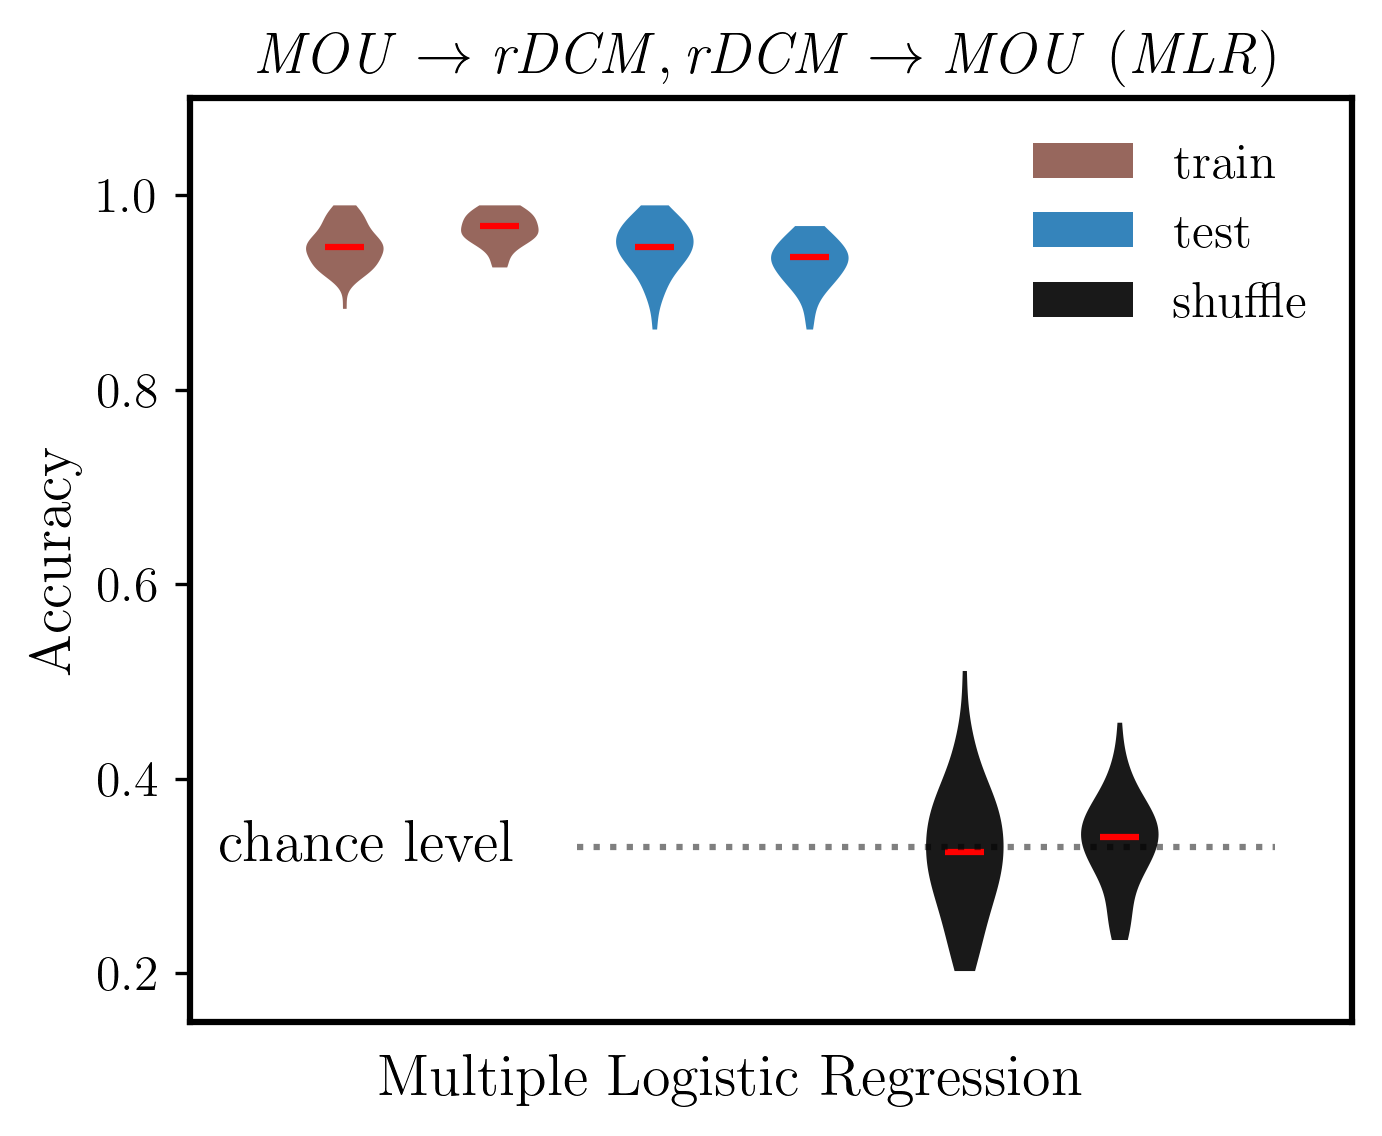

In [67]:
# Extract MLR results only from acc_mou2dcm
acc = acc_mou2dcm
mlr_train_mou2dcm = acc[(acc['type'] == 'ref') & (acc['clf'] == 'MLR')]
mlr_test_mou2dcm = acc[(acc['type'] == 'tgt') & (acc['clf'] == 'MLR')]
mlr_shuffle_mou2dcm = acc[(acc['type'] == 'shuf') & (acc['clf'] == 'MLR')]

dist_mou2dcm_mlr = np.vstack((mlr_train_mou2dcm['score'], mlr_test_mou2dcm['score'], mlr_shuffle_mou2dcm['score']))

# Extract MLR results only from acc_dcm2mou
acc = acc_dcm2mou
mlr_train_dcm2mou = acc[(acc['type'] == 'ref') & (acc['clf'] == 'MLR')]
mlr_test_dcm2mou = acc[(acc['type'] == 'tgt') & (acc['clf'] == 'MLR')]
mlr_shuffle_dcm2mou = acc[(acc['type'] == 'shuf') & (acc['clf'] == 'MLR')]

dist_dcm2mou_mlr = np.vstack((mlr_train_dcm2mou['score'], mlr_test_dcm2mou['score'], mlr_shuffle_dcm2mou['score']))

# Interleave the arrays (MOU->DCM and DCM->MOU alternating)
combined_transfer_mlr = np.empty((dist_mou2dcm_mlr.shape[0] + dist_dcm2mou_mlr.shape[0], dist_mou2dcm_mlr.shape[1]), dtype=dist_mou2dcm_mlr.dtype)
combined_transfer_mlr[0::2, :] = dist_mou2dcm_mlr
combined_transfer_mlr[1::2, :] = dist_dcm2mou_mlr

colors = ['C5', 'C5', 'C0', 'C0', 'Black', 'Black']

fig, ax = plt.subplots(figsize=(5, 4), dpi=300, facecolor="w")

plt.rcParams['text.usetex'] = True
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.family'] = 'serif'

# Model fit
plots = ax.violinplot(combined_transfer_mlr.T, vert=True, showmedians=True, showextrema=False, 
                      widths=0.5, points=100, bw_method=0.5)

# Set the color of the violin patches
for pc, color in zip(plots['bodies'], colors):
    pc.set_facecolor(color)
    pc.set_alpha(0.9)

# Set median markers to red
plots['cmedians'].set_colors(['red'] * len(plots['cmedians'].get_segments()))

ax.set_ylabel('Accuracy', fontsize=14, weight='bold')
ax.set_title(r'$\mathit{MOU \to rDCM, rDCM \to MOU\ (MLR)}$', fontsize=14)
ax.set_ylim(0.15, 1.1)
ax.tick_params(axis='y', labelsize=12)

# Chance level line with label
ax.plot([2.5, 7], [chance_level]*2, ':k', alpha=0.5)
ax.text(2.1, chance_level, 'chance level', fontsize=14, va='center', ha='right')

ax.set_xlim(0, 7.5)
# Remove x ticks and labels
ax.set_xticks([])

# Add label at the bottom
ax.text(3.5, 0.075, 'Multiple Logistic Regression', fontsize=14, weight='bold', ha='center', transform=ax.transData)

# Make frame thicker
for spine in ax.spines.values():
    spine.set_linewidth(1.5)

# Add legend with no bounding box
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='C5', alpha=0.9, label='train'),
                   Patch(facecolor='C0', alpha=0.9, label='test'),
                   Patch(facecolor='Black', alpha=0.9, label='shuffle')]
ax.legend(handles=legend_elements, loc='upper right', fontsize=12, frameon=False)

fname = out_pth + '/transferLearning_MOU-rDCM_MLR_only.svg' 
plt.savefig(fname, transparent=None, dpi='figure', format='svg',
    facecolor='auto', edgecolor='auto', bbox_inches='tight')

plt.show()

In [66]:
out_pth

'/media/nicolas/KINGSTON/retNet_final/output'

## Feature importance detection

In [ ]:
# rois_sorted = [
#         'V1 vf',
#         'V1 vp',
#         'V1 df', 
#         'V1 dp',
#         'V2 vf',
#         'V2 vp',
#         'V2 df', 
#         'V2 dp',
#         'V3 vf',
#         'V3 vp',
#         'V3 df', 
#         'V3 dp',
#         'V1 vf',
#         'V1 vp',
#         'V1 df', 
#         'V1 dp',
#         'V2 vf',
#         'V2 vp',
#         'V2 df', 
#         'V2 dp',
#         'V3 vf',
#         'V3 vp',
#         'V3 df', 
#         'V3 dp']



### MOU features

In [71]:
# quick fix to get coefficients from mlr estimator in pipeline
def get_coef(clf):
    return clf.coef_  # repeat classification

clf = dict_clf['MLR'] # MLR
print(clf)

rkgs_MOU = np.zeros((cvs.get_n_splits(), 24**2))

i_rep = 0
for train_ind, test_ind in cvs.split(X_mou, y):
    
    # wrap classifier to be fitted to data to calculate the ranking
    feature_select = RFE(clf, n_features_to_select=10, step=10,
                         importance_getter=get_coef)
    
    # perform RFE
    feature_select.fit(X_mou[train_ind,:], y[train_ind])
    rkgs_MOU[i_rep,:] = feature_select.ranking_
    i_rep += 1

LogisticRegression(max_iter=500, random_state=0)


In [72]:
mean_rkg = np.mean(rkgs_MOU, axis=0)

#print(np.argsort(mean_rkg))

i_roi = np.repeat(np.arange(24).reshape(-1,1), 24, axis=1).flatten()
j_roi = np.repeat(np.arange(24).reshape(1,-1), 24, axis=0).flatten()

mask_info_feat = np.zeros((24,24))
for ii in np.argsort(mean_rkg)[:20]:
    print(f'from {rois_sorted[i_roi[ii]]} to {rois_sorted[j_roi[ii]]}')
    mask_info_feat[i_roi[ii], j_roi[ii]] = 1



mask_info_feat_MOU = mask_info_feat

from V1 vp to V3 vp
from V2 df to V1 df
from V3 dp to V2 df
from V2 df to V1 df
from V2 df to V2 df
from V2 df to V2 df
from V2 dp to V2 dp
from V2 dp to V1 df
from V1 df to V1 df
from V1 df to V1 df
from V2 dp to V1 df
from V1 vp to V3 vp
from V3 dp to V2 df
from V1 df to V2 df
from V2 dp to V2 dp
from V1 df to V2 df
from V1 vp to V2 vf
from V3 df to V3 df
from V3 df to V3 df
from V1 dp to V2 df


In [73]:
# Save the EC ferature ranking arrays
save_path = "/home/nicolas/Documents/GitHubProjects/retNet/docs_local/source/notebooks/"

np.save(os.path.join(save_path, 'rkgs_MOU.npy'), rkgs_MOU)

print(f"Saved rkgs_MOU.npy with shape: {rkgs_MOU.shape}")


Saved rkgs_MOU.npy with shape: (50, 576)


### rDCM features

In [74]:
# quick fix to get coefficients from mlr estimator in pipeline
def get_coef(clf):
    return clf.coef_  # repeat classification

clf = dict_clf['MLR'] # MLR
print(clf)

rkgs_rDCM = np.zeros((cvs.get_n_splits(), 24**2))

i_rep = 0
for train_ind, test_ind in cvs.split(X_dcm, y):
    
    # wrap classifier to be fitted to data to calculate the ranking
    feature_select = RFE(clf, n_features_to_select=10, step=10,
                         importance_getter=get_coef)
    
    # perform RFE
    feature_select.fit(X_dcm[train_ind,:], y[train_ind])
    rkgs_rDCM[i_rep,:] = feature_select.ranking_
    i_rep += 1

LogisticRegression(max_iter=500, random_state=0)


In [75]:
mean_rkg = np.mean(rkgs_rDCM, axis=0)

#print(np.argsort(mean_rkg))

i_roi = np.repeat(np.arange(24).reshape(-1,1), 24, axis=1).flatten()
j_roi = np.repeat(np.arange(24).reshape(1,-1), 24, axis=0).flatten()

mask_info_feat = np.zeros((24,24))
for ii in np.argsort(mean_rkg)[:20]:
    print(f'from {rois_sorted[i_roi[ii]]} to {rois_sorted[j_roi[ii]]}')
    mask_info_feat[i_roi[ii], j_roi[ii]] = 1



mask_info_feat_rDCM = mask_info_feat

from V2 df to V2 df
from V2 dp to V1 df
from V3 df to V1 df
from V2 df to V1 df
from V2 df to V1 df
from V3 dp to V2 df
from V2 df to V2 df
from V2 dp to V3 df
from V2 dp to V3 df
from V2 dp to V1 df
from V2 df to V3 df
from V2 df to V1 dp
from V2 df to V3 dp
from V3 df to V1 df
from V2 df to V1 dp
from V2 df to V3 df
from V3 df to V1 df
from V2 df to V3 dp
from V2 df to V1 dp
from V3 dp to V2 df


In [76]:
# Save the EC ferature ranking arrays
save_path = "/home/nicolas/Documents/GitHubProjects/retNet/docs_local/source/notebooks/"

np.save(os.path.join(save_path, 'rkgs_rDCM.npy'), rkgs_rDCM)

print(f"Saved rkgs_rDCM.npy with shape: {rkgs_rDCM.shape}")


Saved rkgs_rDCM.npy with shape: (50, 576)


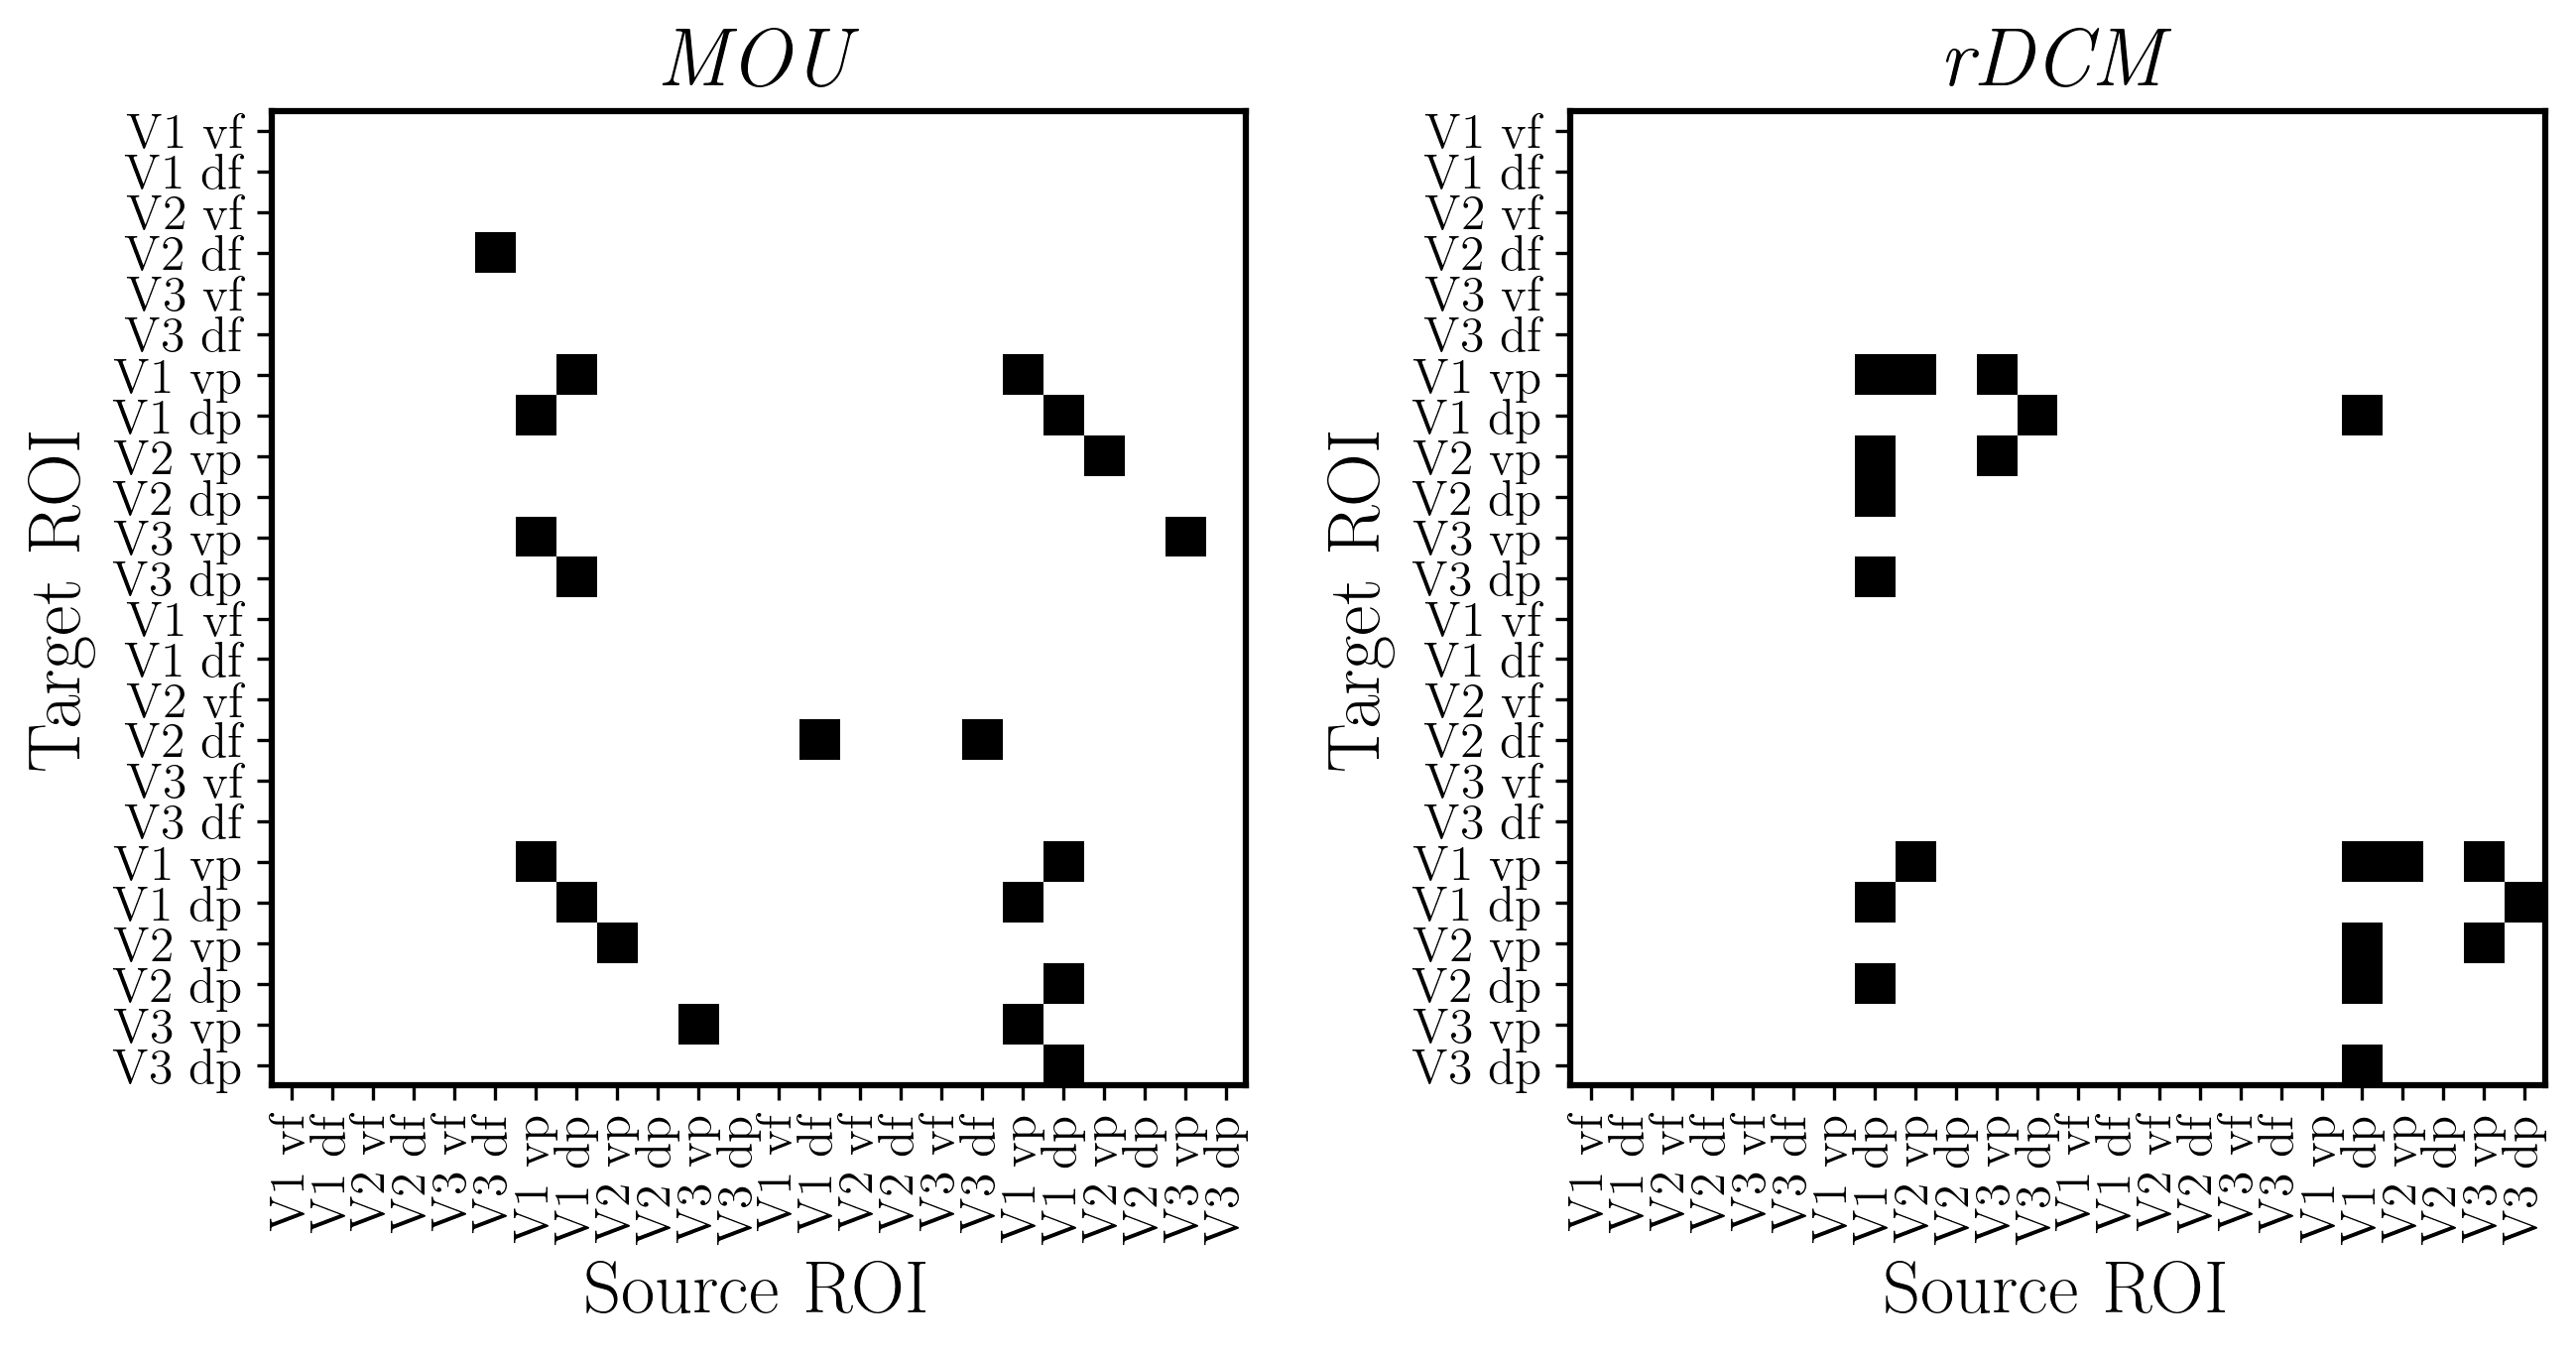

In [82]:
plt.rcParams['text.usetex'] = True
plt.rcParams['font.weight'] = 'bold'
plt.rcParams['font.family'] = 'serif'

fig, ax = plt.subplots(1, 2, figsize=(9, 5), dpi=300, facecolor="w")

EC_max = max(np.max(mask_info_feat_MOU), np.max(mask_info_feat_rDCM))

# MOU plot
im_vfm = ax[0].imshow(mask_info_feat_MOU[np.ix_(new_order, new_order)], vmin=0, vmax=EC_max, cmap='Greys')
ax[0].set_xlabel('Source ROI', fontsize=18, weight='bold')
ax[0].set_xticks(np.arange(len(rois_sorted)))
ax[0].set_xticklabels(labels=rois_sorted, rotation=90, fontsize=12)
ax[0].set_ylabel('Target ROI', fontsize=18, weight='bold')
ax[0].set_yticks(np.arange(len(rois_sorted)))
ax[0].set_yticklabels(labels=rois_sorted, rotation=0, fontsize=12)
ax[0].set_title(r'$\mathit{MOU}$', fontsize=20)

# rDCM plot
im_rs = ax[1].imshow(mask_info_feat_rDCM.T[np.ix_(new_order, new_order)], vmin=0, vmax=EC_max, cmap='Greys')
ax[1].set_xlabel('Source ROI', fontsize=18, weight='bold')
ax[1].set_xticks(np.arange(len(rois_sorted)))
ax[1].set_xticklabels(labels=rois_sorted, rotation=90, fontsize=12)
ax[1].set_ylabel('Target ROI', fontsize=18, weight='bold')
ax[1].set_yticks(np.arange(len(rois_sorted)))
ax[1].set_yticklabels(labels=rois_sorted, rotation=0, fontsize=12)
ax[1].set_title(r'$\mathit{rDCM}$', fontsize=20)

# Make frame thicker for both subplots
for a in ax:
    for spine in a.spines.values():
        spine.set_linewidth(1.5)

plt.tight_layout()

# Save as SVG
fname = out_pth + '/greatLinks.svg' 
plt.savefig(fname, transparent=None, dpi='figure', format='svg',
    facecolor='auto', edgecolor='auto', bbox_inches='tight')

plt.show()